In [1]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
import xarray as xr
import rasterio
import geopandas as gpd
import os
from scipy import signal
from scipy.signal import detrend
from sklearn.preprocessing import StandardScaler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.prepared import prep 
from rasterio.features import geometry_mask
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy import stats
import shapely.geometry as sgeom
warnings.filterwarnings('ignore')

In [2]:
##定义预处理函数
##时间切片
##时间切片
def time_sel(data,yearbegin,yearend):
    data= data.sel(time=slice(f'{yearbegin}-01-01', f'{yearend}-12-31'))
    return data
def detrend_weather(data):
    # 去除季节趋势
    lon=data['lon']
    lat=data['lat']
    time=data['time']
    data=data.values.reshape((12, int(len(data)/12), len(lat), len(lon)), order='F').transpose((1,0,2,3))
    data_season = np.mean(data, axis=0)
    data_diff = data - data_season
    data_diff = data_diff.transpose((1,0,2,3)).reshape((len(time),len(lat), len(lon)), order='F')
    data_diff = np.ma.masked_array(data_diff, mask=np.isnan(data))
    data_diff=xr.DataArray(data_diff, coords=[time,lat,lon], dims=['time', 'lat','lon'])
    ##去长期趋势
    data_detrend = signal.detrend(data_diff.fillna(0), axis=0, type='linear', bp=0)
    data_detrend=xr.DataArray(data_detrend, coords=[time,lat,lon], dims=['time', 'lat','lon'])
    return data_detrend

In [3]:
def trans_lon(ds):
    lon_name = 'lon'  #你的nc文件中经度的命名
    ds['longitude_adjusted'] = xr.where(
        ds[lon_name] > 180,
        ds[lon_name] - 360,
        ds[lon_name])
    ds = (
        ds
        .swap_dims({lon_name: 'longitude_adjusted'})
        .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted)})
        .drop(lon_name))
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds

In [4]:
##全球地图
def capitalize_words(s):
    # 检查元素是否是字符串，如果是，就进行首字母大写操作，如果不是，返回原始值
    if isinstance(s, str):
        return ' '.join(word.capitalize() for word in s.split())
    else:
        return s

Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)
BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")
BRA_shp.rename(columns={'NAME_1': 'loc'}, inplace=True)

In [5]:
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/surface_pressure/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
slp= xr.open_mfdataset(files, combine='nested', concat_dim='time')
slp=slp.rename({'longitude': 'lon'})
slp=slp.rename({'latitude': 'lat'})

In [6]:
# 指定包含所有文件的文件夹路径
folder_path ='/Users/limenghan/Desktop/气候数据/气象要素/era5_hgt/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
hgt= xr.open_mfdataset(files, combine='nested', concat_dim='time')
# 如果需要，可以在这里进行进一步的数据处理或操作
# 最后，保存合并后的 Dataset 到一个新的 nc 文件
hgt= hgt.rename({'longitude': 'lon'})
hgt= hgt.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(hgt.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(hgt.lat)/180), int(len(hgt.lon)/360)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    hgt= hgt.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()

In [7]:
##处理气象要素数据
##1980到2017，三月滑动平均
##先去趋势
slp=slp['sp']
hgt200=hgt.sel(level=200)['z']
hgt500=hgt.sel(level=500)['z']
hgt850=hgt.sel(level=850)['z']
##时间切片
def time_sel(data,yearbegin,yearend):
    data= data.sel(time=slice(f'{yearbegin}-01-01', f'{yearend}-12-31'))
    return data

hgt200=time_sel(hgt200,1980,2020)
hgt500=time_sel(hgt500,1980,2020)
hgt850=time_sel(hgt850,1980,2020)
slp=time_sel(slp,1980,2020)
def detrend_weather(data):
    # 去除季节趋势
    lon=data.lon
    lat=data.lat
    time=data.time
    data=data.values.reshape((12, int(len(data)/12), len(lat), len(lon)), order='F').transpose((1,0,2,3))
    data_season = np.mean(data, axis=0)
    data_diff = data - data_season
    data_diff = data_diff.transpose((1,0,2,3)).reshape((len(time),len(lat), len(lon)), order='F')
    data_diff = np.ma.masked_array(data_diff, mask=np.isnan(data))
    data_diff=xr.DataArray(data_diff, coords=[time,lat,lon], dims=['time', 'lat','lon'])
    ##去长期趋势
    data_detrend = signal.detrend(data_diff.fillna(0), axis=0, type='linear', bp=0)
    data_detrend=xr.DataArray(data_detrend, coords=[time,lat,lon], dims=['time', 'lat','lon'])
    return data_detrend
hgt200=detrend_weather(hgt200)
hgt500=detrend_weather(hgt500)
hgt850=detrend_weather(hgt850)
slp=detrend_weather(slp)
hgt200=time_sel(hgt200,1980,2020)
hgt500=time_sel(hgt500,1980,2020)
hgt850=time_sel(hgt850,1980,2020)
slp=time_sel(slp,1980,2020)

In [8]:
##vwnd
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/v_component_of_wind/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
vwnd= xr.open_mfdataset(files, combine='nested', concat_dim='time')
vwnd= vwnd.rename({'longitude': 'lon'})
vwnd= vwnd.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(vwnd.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(vwnd.lat)/90), int(len(vwnd.lon)/180)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    vwnd= vwnd.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
##uwnd
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/u_component_of_wind/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
uwnd= xr.open_mfdataset(files, combine='nested', concat_dim='time')
uwnd= uwnd.rename({'longitude': 'lon'})
uwnd= uwnd.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(uwnd.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(uwnd.lat)/90), int(len(uwnd.lon)/180)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    uwnd= uwnd.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
uwnd850=uwnd.sel(level=850)['u']
vwnd850=vwnd.sel(level=850)['v']
uwnd850=time_sel(uwnd850,1978,2018)
vwnd850=time_sel(vwnd850,1978,2018)
uwnd850=detrend_weather(uwnd850)
vwnd850=detrend_weather(vwnd850)
uwnd850=time_sel(uwnd850,1979,2017)
vwnd850=time_sel(vwnd850,1979,2017)


In [9]:
for i in ['slp','hgt850','hgt200','hgt500']:
    locals()[f'{i}']=trans_lon(locals()[f'{i}'])

In [10]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ============================
# 1️⃣ 读取海冰数据
# ============================
sic_file = "/Volumes/limenghan/气候变率/HadISST_ice.nc"
print("Loading SIC dataset...")
sic = xr.open_dataset(sic_file)['sic']

# 坐标标准化
def standardize_coords(da):
    coords = list(da.coords)
    if 'latitude' not in coords:
        lat_name = next(k for k in coords if 'lat' in k)
        da = da.rename({lat_name: 'latitude'})
    if 'longitude' not in coords:
        lon_name = next(k for k in coords if 'lon' in k)
        da = da.rename({lon_name: 'longitude'})
    return da

sic = standardize_coords(sic)

# 重采样到月起点
sic_ms = sic.resample(time='MS').mean(dim='time', skipna=True)
time_idx = pd.to_datetime(sic_ms.time.values)

# ============================
# 2️⃣ 区域选择与加权平均
# ============================
def select_region(da, lat1, lat2, lon1, lon2):
    # 纬度 slice
    if da.latitude[0] > da.latitude[-1]:
        lat_slice = slice(max(lat1, lat2), min(lat1, lat2))
    else:
        lat_slice = slice(min(lat1, lat2), max(lat1, lat2))
    
    # 经度 wrap-around
    if lon1 <= lon2:
        da_sel = da.sel(latitude=lat_slice, longitude=slice(lon1, lon2))
    else:
        da1 = da.sel(latitude=lat_slice, longitude=slice(lon1, da.longitude.max().item()))
        da2 = da.sel(latitude=lat_slice, longitude=slice(da.longitude.min().item(), lon2))
        da_sel = xr.concat([da1, da2], dim='longitude').sortby('longitude')
    
    if da_sel.sizes['latitude'] == 0 or da_sel.sizes['longitude'] == 0:
        print(f"Warning: empty selection lat({lat1},{lat2}) lon({lon1},{lon2})")
    return da_sel

def weighted_mean(da):
    weights = np.cos(np.deg2rad(da.latitude))
    return (da * weights).mean(dim=['latitude', 'longitude'], skipna=True)

# ============================
# 3️⃣ 计算海冰指数
# ============================
ice_df = pd.DataFrame(index=time_idx)

# 北极/南极总海冰
ice_df['NH_ice'] = weighted_mean(select_region(sic_ms, 50, 90, -180, 180))
ice_df['SH_ice'] = weighted_mean(select_region(sic_ms, -90, -50, -180, 180))

# 南极海冰偶极: Weddell - Ross
weddell = select_region(sic_ms, -70, -50, -70, 20)
ross    = select_region(sic_ms, -70, -50, 160, -130)
ice_df['Antarctic_Dipole'] = weighted_mean(weddell) - weighted_mean(ross)

# 南极半岛–Amundsen–Ross
peninsula = select_region(sic_ms, -70, -60, -90, -50)
amundsen_ross = select_region(sic_ms, -75, -65, 160, -130)
ice_df['Peninsula_Amundsen_Ross'] = weighted_mean(peninsula) + weighted_mean(amundsen_ross)

# 巴伦支-喀拉
barents = select_region(sic_ms, 70, 80, 20, 60)
kara    = select_region(sic_ms, 70, 80, 60, 90)
ice_df['Barents_Kara'] = weighted_mean(barents) + weighted_mean(kara)

# 楚科奇-白令-拉普捷夫
chukchi = select_region(sic_ms, 65, 75, 170, -160)
bering  = select_region(sic_ms, 60, 70, -170, -150)
laptev  = select_region(sic_ms, 70, 80, 100, 140)
ice_df['Chukchi_Bering_Laptev'] = weighted_mean(chukchi) + weighted_mean(bering) + weighted_mean(laptev)

# ============================
# 4️⃣ 去季节、去趋势、标准化
# ============================
def remove_monthly_mean(series):
    return series - series.groupby(series.index.month).transform('mean')

def detrend_series(y):
    y = np.asarray(y, dtype=float)
    isnan = np.isnan(y)
    if isnan.all(): return y
    t = np.arange(len(y))[~isnan].reshape(-1, 1)
    y_nonan = y[~isnan]
    if len(y_nonan) < 3: return y
    lr = LinearRegression().fit(t, y_nonan)
    y_out = np.full_like(y, np.nan, dtype=float)
    y_out[~isnan] = y_nonan - lr.predict(t)
    return y_out

def zscore(x):
    x = np.asarray(x, dtype=float)
    mn, sd = np.nanmean(x), np.nanstd(x)
    if sd == 0 or np.isnan(sd): return x - mn
    return (x - mn) / sd

for col in ice_df.columns:
    s = pd.Series(ice_df[col].values, index=time_idx)
    s = remove_monthly_mean(s)
    s = detrend_series(s.values)
    s = zscore(s)
    ice_df[col] = s

# 双重索引
ice_df['year'] = ice_df.index.year
ice_df['month'] = ice_df.index.month
df_out = ice_df.set_index(['year', 'month']).sort_index()

# ============================
# 5️⃣ 读取气候数据 & 去趋势 & 去季节
# ============================
climate_series = pd.read_excel('/Volumes/limenghan/气候变率/ClimateSeries.xlsx', index_col=[0,1])
climate_series = climate_series['1976':'2017']

def detrend(column):
    valid = column.dropna()
    if len(valid) < 2:
        return column
    X = np.arange(len(valid)).reshape(-1, 1)
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    trend = model.predict(X)
    deseasoned = y - trend
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

def remove_seasonality(column):
    valid = column.dropna()
    if len(valid) < 2: return column
    month_index = valid.index.get_level_values('month')
    month_dummies = pd.get_dummies(month_index)
    X = month_dummies.values
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    seasonal = model.predict(X)
    deseasoned = y - seasonal
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

climate_series_detrended = climate_series.apply(detrend)
climate_series_detrended = climate_series_detrended.groupby(level='month').apply(lambda df: df.apply(remove_seasonality))
climate_series_detrended = climate_series_detrended.reset_index(level=0, drop=True)
climate_series_detrended = climate_series_detrended.sort_values(by=['year', 'month'])

# ============================
# 6️⃣ 去除 Nino3.4 与 IOB 信号
# ============================
def orth_multi(A, b):
    """将b在多列A上正交化，返回去除A投影后的b"""
    A = np.asarray(A)
    b = np.asarray(b)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    valid = ~np.isnan(A).any(axis=1) & ~np.isnan(b)
    if valid.sum() < 3:
        return b
    A_valid = A[valid]
    b_valid = b[valid]
    coef = np.linalg.lstsq(A_valid, b_valid, rcond=None)[0]
    b_resid = b_valid - A_valid @ coef
    b_out = np.full_like(b, np.nan, dtype=float)
    b_out[valid] = b_resid
    return b_out

def remove_signals(df, signals=['Nino34', 'IOB']):
    """从 df 中去除指定气候信号的线性投影"""
    existing_signals = [s for s in signals if s in df.columns]
    if not existing_signals:
        print("⚠️ 未找到任何指定信号列，跳过去信号。")
        return df

    df_out = df.copy()
    A_all = df[existing_signals].dropna(how='any')

    for col in df.columns:
        if col in existing_signals:
            continue
        common_index = A_all.index.intersection(df[col].dropna().index)
        if len(common_index) == 0:
            continue
        A = df.loc[common_index, existing_signals].values
        b = df.loc[common_index, col].values
        df_out.loc[common_index, col] = orth_multi(A, b)
    return df_out

# 对年份进行筛选
start_year = climate_series_detrended.index.get_level_values('year').min()
end_year   = climate_series_detrended.index.get_level_values('year').max()
df_overlap = df_out.loc[
    (df_out.index.get_level_values('year') >= start_year) &
    (df_out.index.get_level_values('year') <= end_year)
]

# 合并 Nino34 与 IOB
df_plus_signals = pd.concat([df_overlap, climate_series_detrended[['Nino34', 'IOB']]], axis=1)

# 去除 Nino34 与 IOB 信号
df_processed = remove_signals(df_plus_signals, signals=['Nino34', 'IOB'])
df_processed = df_processed.drop(columns=['Nino34', 'IOB'], errors='ignore')

# ============================
# ✅ 最终结果
# ============================
print("✅ 去除 Nino3.4 与 IOB 信号完成！")
print(df_processed.head())

Loading SIC dataset...
✅ 去除 Nino3.4 与 IOB 信号完成！
              NH_ice    SH_ice  Antarctic_Dipole  Peninsula_Amundsen_Ross  \
year month                                                                  
1976 1      0.762276  0.144336          0.333336                 1.059719   
     2      0.697589  0.634514          0.577264                 1.110092   
     3      0.724929  1.666558          0.125437                 3.199734   
     4      0.836091 -1.232395         -3.027264                 1.401437   
     5      0.602295 -0.041239         -3.106786                 2.810050   

            Barents_Kara  Chukchi_Bering_Laptev  
year month                                       
1976 1          0.552656               0.177908  
     2          0.544110               0.006236  
     3          0.177710               0.266074  
     4         -0.092563               0.385650  
     5         -0.121103               0.913614  


In [11]:
##玉米
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/作物数据/maize/GDHY_maize/maize_second/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = glob(os.path.join(folder_path, '*.nc4'))
# 按文件名中的年份进行排序（假设文件名后四位代表年份）
files.sort(key=lambda f: int(os.path.basename(f)[-8:-4]))
# 用来存储所有读取的 Dataset 对象
datasets = []
# 遍历每个文件
for file in files:
    # 读取当前的 nc 文件
    ds = xr.open_dataset(file)
    # 提取文件名的后四位作为时间
    time_value = int(os.path.basename(file)[-8:-4])  # 假设文件名最后四位是年份
    # 给这个 Dataset 添加一个新的 'time' 维度
    ds = ds.assign_coords(time=[time_value])
    # 将 Dataset 添加到列表中
    datasets.append(ds)
# 使用 concat 将所有文件合并
maize = xr.concat(datasets, dim='time')
maize = maize['var']
crop_name=['maize']
for i in crop_name:
    locals()[f'{i}']=trans_lon(locals()[f'{i}'])

def mask_outside_geodf(dataarray: xr.DataArray, geodf):
    """
    将 geodf 区域外的格点置为 NaN（区域内保留）。
    适用于规则网格：lat/lon 为 1D 坐标。
    自动处理 lon=0..360 与 lon=-180..180 的不一致。
    """

    da = dataarray

    # ---- 1) 经度体系对齐：如果 da.lon 是 0..360 而 shapefile 用 -180..180，则转换 ----
    if "lon" in da.coords:
        lon = da["lon"].values
        # 判断 lon 是否是 0..360
        if np.nanmin(lon) >= 0 and np.nanmax(lon) > 180:
            da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180)).sortby("lon")

    # ---- 2) 构建掩膜（lat/lon 1D）----
    lons = da["lon"].values
    lats = da["lat"].values
    lon2d, lat2d = np.meshgrid(lons, lats)

    region = prep(geodf.geometry.unary_union)

    # covers 比 contains 更适合栅格点（边界也算内）
    flat_points = [Point(xy) for xy in zip(lon2d.ravel(), lat2d.ravel())]
    mask = np.array([region.covers(p) for p in flat_points], dtype=bool).reshape(lat2d.shape)

    mask_da = xr.DataArray(mask, coords={"lat": da["lat"], "lon": da["lon"]}, dims=("lat", "lon"))

    # ---- 3) 应用掩膜：区域外 -> NaN ----
    return da.where(mask_da)

#裁剪 DataArray
maize_bra= mask_outside_geodf(maize, BRA_shp)
# 例：如果 maize_bra 有 time 维
if "time" in maize_bra.dims:
    maize2d = maize_bra.mean("time", skipna=True)
else:
    maize2d = maize_bra

In [ ]:
maize2d

In [12]:

def calculate_seasonal_standardized_mean(data, start_month, end_month,start_year,end_year):
    """
    计算指定时间段（三个月或跨年的）标准化平均值。

    :param data: xarray.DataArray，包含时间维度 'time'
    :param start_month: 起始月份（1-12）
    :param end_month: 结束月份（1-12，跨年时需要小于起始月份）
    :return: 标准化的季节平均值，按年份分组
    """
    # 提取年份和月份信息
    if start_month<end_month:
        data = data.loc[(slice(start_year,end_year), [start_month, start_month+1, end_month])]
        ##三月平均（SON）
        data_averages =data.groupby('year').mean()
    elif start_month==11:
        # 提取第一个切片（前一年 11 月和 12 月）
        part1 = data.loc[(slice(start_year, end_year), [11, 12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year + 1, end_year+1), [1])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[1] = data[1].shift(-1)  # 将1月对齐到上一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    elif start_month==12:
        # 提取第一个切片（前一年 12 月）
        part1 = data.loc[(slice(start_year -1, end_year - 1), [12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year, end_year), [1,2])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[12] = data[12].shift(1)  # 将12月对齐到下一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    return data_averages

AD_NDJ_1_mean_std=calculate_seasonal_standardized_mean(df_processed['Antarctic_Dipole'], 11, 1,1980,2015)
AD_NDJ_1_mean_std=(AD_NDJ_1_mean_std - AD_NDJ_1_mean_std.mean()) / AD_NDJ_1_mean_std.std()

In [13]:
##气象要素去nino、IOB
def orth(A,b):
    temp = np.dot(np.transpose(A),b)/np.dot(np.transpose(A),A)
    b_=  np.dot(temp,A)
    b_new = b-b_
    return b_new
def orth_hgt(data, month, year):

    # --- 提取指数 ---
    nino = climate_series_detrended['Nino34']
    iob  = climate_series_detrended['IOB']

    # --- 时间范围 ---
    if year == 0:
        time_sel = slice(1981, 2016)
    else:
        time_sel = slice(1980, 2015)

    # --- 选定对应月份 ---
    nino_ = nino.loc[(time_sel, season_months[month])]
    iob_  = iob.loc[(time_sel, season_months[month])]

    # --- lat / lon / time 尺寸 ---
    nlat = len(data.lat)
    nlon = len(data.lon)
    ntime = len(data.time)

    # --- 创建结果数组 ---
    result = np.zeros((nlat, nlon, ntime))

    # --- 套循环处理 ---
    for ilat, alat in enumerate(data.lat.values):
        for ilon, alon in enumerate(data.lon.values):

            # 提取格点数据 (time,)
            y0 = data.sel(lat=alat, lon=alon).values

            # 第一步：去除 Nino34 线性部分
            y1 = orth(nino_.values, y0)

            # 第二步：去除 IOB 线性部分
            y2 = orth(iob_.values, y1)

            # 存入结果
            result[ilat, ilon, :] = y2

    # --- 转为 DataArray ---
    data_ = xr.DataArray(
        result,
        coords={'lat': data.lat, 'lon': data.lon, 'time': data.time},
        dims=['lat', 'lon', 'time']
    )

    return data_


In [14]:

def deseason_detrend_xr(da):
    """
    对 DataArray (time, lat, lon)：
    1. 去季节循环（月气候态）
    2. 对每个格点沿 time 维做线性去趋势
    
    返回：去季节 + 去趋势后的 anomaly
    """

    # ---------- 1. 去季节循环 ----------
    clim = da.groupby('time.month').mean('time', skipna=True)
    da_anom = da.groupby('time.month') - clim

    # ---------- 2. 去线性趋势（逐格点） ----------
    t = xr.DataArray(
        np.arange(da_anom.sizes['time']),
        dims='time',
        coords={'time': da_anom.time}
    )

    def detrend_1d(y, x):
        mask = np.isfinite(y)
        if mask.sum() < 2:
            return y * np.nan
        p = np.polyfit(x[mask], y[mask], 1)
        return y - (p[0] * x + p[1])

    da_detrend = xr.apply_ufunc(
        detrend_1d,
        da_anom,
        t,
        input_core_dims=[['time'], ['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[da.dtype],
    )

    return da_detrend


In [15]:
#全球海温数据
sst = xr.open_dataset(
    '/Users/limenghan/Desktop/气候数据/HadISST_sst.nc',
    decode_cf=True,
    mask_and_scale=True
)

lon_name = 'longitude'  # whatever name is in the data
# Adjust lon values to make sure they are within (-180, 180)
sst['_longitude_adjusted'] = xr.where(
    sst[lon_name] > 180,
    sst[lon_name] - 360,
    sst[lon_name])
# reassign the new coords to as the main lon coords
# and sort DataArray using new coordinate values
sst = (
    sst
    .swap_dims({lon_name: '_longitude_adjusted'})
    .sel(**{'_longitude_adjusted': sorted(sst._longitude_adjusted)})
    .drop(lon_name))
sst = sst.rename({'_longitude_adjusted': lon_name})
##时间切片
sst= sst.sel(time=slice('1979-01-01', '2017-12-31'))
##lon和lat
lon = np.array(sst['longitude'])
lat = np.array(sst['latitude'])
sst= sst.rename({'longitude': 'lon'})
sst= sst.rename({'latitude': 'lat'})
sst = sst['sst']

# HadISST 关键一步：手动 mask
sst = sst.where(sst > -900)

sst_dt=deseason_detrend_xr(sst)
sst_dt=time_sel(sst_dt,1980,2020)
sst_dt

<xarray.DataArray (lat: 180, lon: 360, time: 456)>
array([[[           nan,            nan,            nan, ...,
         -7.0053560e-04, -7.0575066e-04,            nan],
        [           nan,            nan,            nan, ...,
         -1.3100768e-07,  1.0748879e-07,            nan],
        [           nan,            nan,            nan, ...,
         -7.1810686e-04, -7.2347140e-04,            nan],
        ...,
        [           nan,            nan,            nan, ...,
         -7.2342844e-04, -7.2886795e-04, -7.3442661e-04],
        [           nan,            nan,            nan, ...,
         -7.1594538e-04, -7.2134426e-04, -7.2686234e-04],
        [           nan,            nan,            nan, ...,
         -7.2052452e-04, -7.2589476e-04,            nan]],

       [[           nan,            nan,            nan, ...,
         -1.7690942e-07, -1.7697856e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.7695730e-07, -1.7703832e-07,            nan],
        [           nan,            nan,            nan, ...,
         -1.9146626e-07, -1.9153941e-07,            nan],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-16T12:00:00 ... 2017-12-16T12:00:00
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [16]:

## 时间切片
def time_sel(data, yearbegin, yearend):
    data = data.sel(time=slice(f'{yearbegin}-01-01', f'{yearend}-12-31'))
    return data

## 去季节循环 + 去线性趋势
def detrend_weather(data):
    lon = data['lon']
    lat = data['lat']
    time = data['time']

    data_np = data.values.reshape((12, int(len(data) / 12), len(lat), len(lon)), order='F').transpose((1, 0, 2, 3))
    data_season = np.mean(data_np, axis=0)
    data_diff = data_np - data_season
    data_diff = data_diff.transpose((1, 0, 2, 3)).reshape((len(time), len(lat), len(lon)), order='F')

    # 这里建议用 data_diff 本身来做 mask，更安全
    data_diff = np.ma.masked_array(data_diff, mask=np.isnan(data_diff))
    data_diff = xr.DataArray(data_diff, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    data_detrend = signal.detrend(data_diff.fillna(0), axis=0, type='linear', bp=0)
    data_detrend = xr.DataArray(data_detrend, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    return data_detrend
## 读取 ERA5-Land soil moisture
ds = xr.open_dataset('/Volumes/limenghan/ERA5/soil_moisture/era5_monthly_swvl2_swvl3_1950_2024.nc')

# 坐标改名
rename_dict = {}
if 'longitude' in ds.coords:
    rename_dict['longitude'] = 'lon'
if 'latitude' in ds.coords:
    rename_dict['latitude'] = 'lat'
if 'valid_time' in ds.coords:
    rename_dict['valid_time'] = 'time'
if rename_dict:
    ds = ds.rename(rename_dict)

# 先时间切片
ds = ds.sel(time=slice('1980-01-01', '2020-12-31'))

# 如果经度是 0~360，转成 -180~180
if ds.lon.max() > 180:
    ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180).sortby('lon')

# 先转成 float32，减少内存
ds = ds.astype('float32')

# =========================================================
# 方法1：如果原始分辨率是规则高分辨率网格，直接 coarsen 到 0.5°
# =========================================================
# 例如 ERA5-Land 常见是 0.1°，那么 5×5 平均后就是 0.5°
dlat = float(ds.lat.diff('lat').mean())
dlon = float(ds.lon.diff('lon').mean())

print('original resolution:', dlat, dlon)

lat_factor = int(round(0.5 / abs(dlat)))
lon_factor = int(round(0.5 / abs(dlon)))

ds_05 = ds.coarsen(lat=lat_factor, lon=lon_factor, boundary='trim').mean()

# =========================================================
# 如果你更想严格定义 0.5° 网格中心，也可以再 assign 一下坐标
# 一般 coarsen 后直接用也可以
# =========================================================

# 裁剪巴西区域
ds_05_bra = ds_05.sel(lon=slice(-75, -34), lat=slice(6, -40))

## 提取第2、3层
sm2 = ds_05_bra['swvl2']
sm3 = ds_05_bra['swvl3']

## 厚度加权平均，得到根区土壤湿度
thk2 = 0.21
thk3 = 0.72
smroot = (sm2 * thk2 + sm3 * thk3) / (thk2 + thk3)
smroot.name = 'smroot'
smroot.attrs['long_name'] = 'Root-zone soil moisture from ERA5-Land layer 2 and 3'
smroot.attrs['units'] = 'm3 m-3'
smroot.attrs['depth'] = '0.07-1.00 m'
smroot.attrs['resolution'] = '0.5 degree'

# 去趋势
smroot = detrend_weather(smroot)
smroot_bra=smroot
smroot_bra

original resolution: -0.25 0.25


<xarray.DataArray (time: 492, lat: 92, lon: 82)>
array([[[-5.2823439e-02, -4.8655778e-02, -1.9894857e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-2.5763322e-02, -2.7303526e-02, -5.0556753e-03, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-5.6235697e-03, -9.2866868e-03,  7.5409643e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        ...,
        [ 2.4565993e-06,  2.4565993e-06,  9.7579393e-04, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06]],

       [[-3.8235877e-02, -3.8226590e-02, -3.1170802e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-2.4408042e-02, -2.8699890e-02,  3.7283972e-03, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-8.4615834e-03, -3.1353533e-03,  6.7007467e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
...
        [-1.2040152e-06, -1.2040152e-06, -1.2758460e-03, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06]],

       [[-2.4386868e-03, -1.4103893e-02,  1.0852376e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-4.6318401e-02,  2.0710785e-02,  2.4517652e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-6.5433264e-02,  1.3740960e-02,  1.7148919e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        ...,
        [ 1.7110054e-06,  1.7110054e-06, -1.4503738e-03, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
  * lat      (lat) float64 5.875 5.375 4.875 4.375 ... -38.62 -39.12 -39.62
  * lon      (lon) float64 -74.88 -74.38 -73.88 -73.38 ... -35.38 -34.88 -34.38

In [17]:
#flux
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/flux/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
flux= xr.open_mfdataset(files, combine='nested', concat_dim='time')
flux= flux.rename({'longitude': 'lon'})
flux= flux.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(flux.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(flux.lat)/360), int(len(flux.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    flux=flux.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
msdwswrf=flux['msdwswrf']
##时间切片
msdwswrf=time_sel(msdwswrf,1980,2020)
msdwswrf=detrend_weather(msdwswrf)
if msdwswrf.lon.max()>180:
    msdwswrf=trans_lon(msdwswrf)
msdwswrf_bra=msdwswrf.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [18]:
#evap
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/evap/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
evap= xr.open_mfdataset(files, combine='nested', concat_dim='time')
evap= evap.rename({'longitude': 'lon'})
evap= evap.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(evap.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(evap.lat)/360), int(len(evap.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    evap= evap.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
evap=evap['e']
##时间切片
evap=time_sel(evap,1980,2020)
evap=detrend_weather(evap)
evap=time_sel(evap,1980,2020)
if evap.lon.max()>180:
    evap=trans_lon(evap)
evap_bra=evap.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [19]:
##dtr
dtr=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.dtr.dat.nc')
dtr=dtr['dtr']
dtr=time_sel(dtr,1980,2020)
dtr=detrend_weather(dtr)
dtr=time_sel(dtr,1980,2020)
if dtr.lon.max()>180:
    dtr=trans_lon(dtr)
dtr_bra=dtr.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [20]:
##cloud
cld=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.cld.dat.nc')
cld=cld['cld']                                                                                                                                                                                       
cld=time_sel(cld,1980,2020)
cld=detrend_weather(cld)
cld=time_sel(cld,1980,2020)
if cld.lon.max()>180:
    cld=trans_lon(cld)
cld_bra=cld.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [21]:
##pre
pre=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.pre.dat.nc')
pre=pre['pre']
pre=time_sel(pre,1980,2020)
pre=detrend_weather(pre)
pre=time_sel(pre,1980,2020)
if pre.lon.max()>180:
    pre=trans_lon(pre)
pre_bra=pre.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [22]:
##tmp
tmp=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.tmp.dat.nc')
tmp=tmp['tmp']
tmp=time_sel(tmp,1980,2020)
tmp=detrend_weather(tmp)
tmp=time_sel(tmp,1980,2020)
if tmp.lon.max()>180:
    tmp=trans_lon(tmp)
tmp_bra=tmp.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [23]:
##vap
vap=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.vap.dat.nc')
vap=vap['vap']
vap=time_sel(vap,1980,2020)
vap=detrend_weather(vap)
vap=time_sel(vap,1980,2020)
if vap.lon.max()>180:
    vap=trans_lon(vap)
vap_bra=vap.sel(lon=slice(-75,-34), lat=slice(-34,6))
# 将值为 0 的点 mask 掉，设为 NaN
tmp_bra = tmp_bra.where(tmp_bra!= 0, np.nan)
vap_bra = vap_bra.where(vap_bra!= 0, np.nan)
##vpd
e0 = 6.108 *np.exp(17.27 * tmp / (tmp + 237.3))
vpd=e0-vap
vpd_bra=vpd.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [24]:
variable_list=['dtr','cld','pre','vpd','evap','msdwswrf','smroot','vap']
for i in variable_list:
    locals()[f'{i}_bra_sort']=locals()[f'{i}_bra'].sortby(['lat', 'lon'])

In [25]:
season_months = {
    'DJF': [12, 1, 2],  # 冬季：12, 1, 2
    'JFM': [1, 2, 3],    # 初春：1, 2, 3
    'FMA': [2, 3, 4],    # 春季：2, 3, 4
    'MAM': [3, 4, 5],    # 春末：3, 4, 5
    'AMJ': [4, 5, 6],    # 初夏：4, 5, 6
    'MJJ': [5, 6, 7],    # 夏季：5, 6, 7
    'JJA': [6, 7, 8],    # 夏季：6, 7, 8
    'JAS': [7, 8, 9],    # 夏末：7, 8, 9
    'ASO': [8, 9, 10],   # 秋季：8, 9, 10
    'SON': [9, 10, 11],  # 秋末：9, 10, 11
    'OND': [10, 11, 12], # 深秋：10, 11, 12
    'NDJ': [11, 12, 1],  # 初冬：11, 12, 1
}

In [26]:

def calculate_seasonal_standardized_mean(data, start_month, end_month, start_year, end_year):
    """
    计算指定年份范围内某个季节（可跨年）的“季节平均”并进行“年际标准化”(z-score)，逐格点计算。

    参数
    ----
    data : xarray.DataArray
        维度至少包含 time（以及可选的 lat/lon 等空间维）
    start_month, end_month : int
        起止月份（1-12）。若 start_month > end_month 表示跨年（如 12-2）。
    start_year, end_year : int
        这里的 year 指“season_year”（季节年）。
        例如 DJF(12-2) 中，2015 DJF 指 2014-12 + 2015-01/02，因此 season_year=2015。

    返回
    ----
    standardized : xarray.DataArray
        维度包含 season_year（以及 lat/lon 等），值为季节平均后的标准化结果
    seasonal_mean : xarray.DataArray
        季节平均（未标准化），方便你检验
    """
    # 1) 确保 time 是 datetime64
    if not np.issubdtype(data.time.dtype, np.datetime64):
        data = data.assign_coords(time=pd.to_datetime(data.time.values))

    month = data.time.dt.month
    year  = data.time.dt.year

    # 2) 生成目标月份列表
    if start_month <= end_month:
        months = list(range(start_month, end_month + 1))
        # 不跨年：season_year 就是自然年
        season_year = year
    else:
        # 跨年：例如 12-2 或 11-1 或 10-2 等
        months = list(range(start_month, 13)) + list(range(1, end_month + 1))
        # 跨年季节：把 start_month..12 这些月份归到下一年（season_year = year+1）
        season_year = xr.where(month >= start_month, year + 1, year)

    # 3) 只保留目标季节月份 & season_year 在 [start_year, end_year]
    mask = month.isin(months) & (season_year >= start_year) & (season_year <= end_year)
    da_season = data.where(mask, drop=True)
    
    # 4) 按 season_year 做季节平均
    season_year_coord = xr.DataArray(
        season_year.where(mask, drop=True).values,
        coords={"time": da_season.time},
        dims="time",
        name="season_year"
    )
    seasonal_mean = da_season.groupby(season_year_coord).mean("time")
    seasonal_mean = seasonal_mean.rename({"group": "season_year"}) if "group" in seasonal_mean.dims else seasonal_mean
    seasonal_mean = seasonal_mean.assign_coords(season_year=sorted(np.unique(season_year_coord.values)))

    # 5) 年际标准化（逐格点）
    clim_mean = seasonal_mean.mean("season_year")
    clim_std  = seasonal_mean.std("season_year")

    standardized = (seasonal_mean - clim_mean) / clim_std

    return standardized


In [27]:

def calculate_seasonal_mean(data, start_month, end_month, start_year, end_year):
    """
    计算指定年份范围内某个季节（可跨年）的“季节平均”并进行“年际标准化”(z-score)，逐格点计算。

    参数
    ----
    data : xarray.DataArray
        维度至少包含 time（以及可选的 lat/lon 等空间维）
    start_month, end_month : int
        起止月份（1-12）。若 start_month > end_month 表示跨年（如 12-2）。
    start_year, end_year : int
        这里的 year 指“season_year”（季节年）。
        例如 DJF(12-2) 中，2015 DJF 指 2014-12 + 2015-01/02，因此 season_year=2015。

    返回
    ----
    standardized : xarray.DataArray
        维度包含 season_year（以及 lat/lon 等），值为季节平均后的标准化结果
    seasonal_mean : xarray.DataArray
        季节平均（未标准化），方便你检验
    """
    # 1) 确保 time 是 datetime64
    if not np.issubdtype(data.time.dtype, np.datetime64):
        data = data.assign_coords(time=pd.to_datetime(data.time.values))

    month = data.time.dt.month
    year  = data.time.dt.year

    # 2) 生成目标月份列表
    if start_month <= end_month:
        months = list(range(start_month, end_month + 1))
        # 不跨年：season_year 就是自然年
        season_year = year
    else:
        # 跨年：例如 12-2 或 11-1 或 10-2 等
        months = list(range(start_month, 13)) + list(range(1, end_month + 1))
        # 跨年季节：把 start_month..12 这些月份归到下一年（season_year = year+1）
        season_year = xr.where(month >= start_month, year + 1, year)

    # 3) 只保留目标季节月份 & season_year 在 [start_year, end_year]
    mask = month.isin(months) & (season_year >= start_year) & (season_year <= end_year)
    da_season = data.where(mask, drop=True)
    
    # 4) 按 season_year 做季节平均
    season_year_coord = xr.DataArray(
        season_year.where(mask, drop=True).values,
        coords={"time": da_season.time},
        dims="time",
        name="season_year"
    )
    seasonal_mean = da_season.groupby(season_year_coord).mean("time")
    seasonal_mean = seasonal_mean.rename({"group": "season_year"}) if "group" in seasonal_mean.dims else seasonal_mean
    seasonal_mean = seasonal_mean.assign_coords(season_year=sorted(np.unique(season_year_coord.values)))

    return seasonal_mean


In [28]:
def series_to_season_year_da(
    s,
    start_month,
    end_month,
    start_year,
    end_year,
    name=None,
    standardize=True,
    ddof=0,
):
    """
    s: pandas.Series, MultiIndex = (year, month), values = 指数
    返回：xarray.DataArray，dim='season_year'
    
    standardize:
        True  -> (x - mean) / std  （推荐，用于 ENSO / IOB）
        False -> 只做季节平均
    """

    if not isinstance(s.index, pd.MultiIndex) or s.index.nlevels != 2:
        raise ValueError("指数必须是 MultiIndex(year, month) 的 pandas.Series")

    # ---------- 月度 -> time ----------
    years  = s.index.get_level_values(0).astype(int)
    months = s.index.get_level_values(1).astype(int)

    time = pd.to_datetime({"year": years, "month": months, "day": 1})
    da = xr.DataArray(
        s.values.astype(float),
        coords={"time": time},
        dims="time",
        name=(name or s.name or "index"),
    )

    m = da.time.dt.month
    y = da.time.dt.year

    # ---------- 定义 season_year ----------
    if start_month <= end_month:
        months_sel = list(range(start_month, end_month + 1))
        season_year = y
    else:
        months_sel = list(range(start_month, 13)) + list(range(1, end_month + 1))
        season_year = xr.where(m >= start_month, y + 1, y)

    mask = (
        m.isin(months_sel)
        & (season_year >= start_year)
        & (season_year <= end_year)
    )

    da_season = da.where(mask, drop=True)

    season_year_coord = xr.DataArray(
        season_year.where(mask, drop=True).values,
        coords={"time": da_season.time},
        dims="time",
        name="season_year",
    )

    # ---------- 季节平均 ----------
    out = da_season.groupby(season_year_coord).mean("time")
    out = out.rename({"group": "season_year"}) if "group" in out.dims else out
    out = out.assign_coords(season_year=np.unique(season_year_coord.values))

    # ---------- 标准化（核心新增部分） ----------
    if standardize:
        mu  = out.mean("season_year")
        sig = out.std("season_year", ddof=ddof)

        out = (out - mu) / sig
        out.attrs["standardized"] = "z-score"
        out.attrs["ddof"] = ddof

    return out


In [29]:
nino34=df_plus_signals['Nino34']
iob=df_plus_signals['IOB']

In [30]:
iob_JFM = series_to_season_year_da(iob, 1, 3, 1981, 2016, name="IOB",standardize=True,)
iob_AMJ = series_to_season_year_da(iob, 4,6, 1981, 2016, name="IOB",standardize=True,)
nino_JFM = series_to_season_year_da(nino34, 1, 3, 1981, 2016, name="Nino34",standardize=True,)
nino_AMJ = series_to_season_year_da(nino34, 4,6, 1981, 2016, name="Nino34",standardize=True,)

In [31]:
sic=sic.rename({"latitude": "lat", "longitude": "lon"})
sic

<xarray.DataArray 'sic' (time: 1868, lat: 180, lon: 360)>
[121046400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1870-01-16T11:59:59.505615234 ... 2025-08-...
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Attributes:
    standard_name:  sea_ice_area_fraction
    long_name:      Monthly 1 degree resolution sea ice concentration
    units:          1
    cell_methods:   time: lat: lon: median

In [32]:
sic_dt=deseason_detrend_xr(sic)
sic_dt=time_sel(sic_dt,1980,2020)
sic_dt

<xarray.DataArray (lat: 180, lon: 360, time: 492)>
array([[[ 0.0035442 ,  0.00278159,  0.00246738, ..., -0.0202463 ,
         -0.02224004, -0.00287893],
        [ 0.00324277,  0.00254356,  0.00222874, ..., -0.02071936,
         -0.0127784 ,  0.00658216],
        [ 0.00324822,  0.00254903,  0.00223423, ..., -0.02070711,
         -0.01276601,  0.00659456],
        ...,
        [ 0.00347417,  0.00277556,  0.00246134, ..., -0.01025993,
         -0.02225368, -0.00269923],
        [ 0.00360324,  0.00284079,  0.00252674, ..., -0.01998351,
         -0.0219771 ,  0.00744865],
        [ 0.00355979,  0.00279722,  0.00248306, ..., -0.02008206,
         -0.02220469,  0.00728549]],

       [[ 0.00298165,  0.00208871,  0.00170826, ..., -0.00577981,
         -0.02293611, -0.00473834],
        [ 0.0029719 ,  0.00207894,  0.00169846, ..., -0.01586636,
         -0.0229582 , -0.00463147],
        [ 0.00288125,  0.00205241,  0.00167186, ..., -0.00592643,
         -0.0230181 , -0.00482054],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-16T12:00:00 ... 2020-12-16T12:00:00
  * lat      (lat) float32 89.5 88.5 87.5 86.5 85.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [33]:
global_varible=['hgt200','hgt500','hgt850','slp','sst_dt','sic_dt','vwnd850','uwnd850']
for i in global_varible:
    locals()[f'{i}_sort']=locals()[f'{i}'].sortby(['lat', 'lon'])

In [36]:
def remove_nino_iob_from_da(da, nino, iob, dim="season_year", add_intercept=True):
    """
    da: xarray.DataArray, dims 包含 dim + (lat, lon...)
    nino/iob: xarray.DataArray, dims = (dim,)
    返回：残差（去信号后）
    """
    da2, nino2, iob2 = xr.align(da, nino, iob, join="inner")

    def _resid(y, x1, x2):
        y  = np.asarray(y, dtype=float)
        x1 = np.asarray(x1, dtype=float)
        x2 = np.asarray(x2, dtype=float)
        valid = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
        if valid.sum() < 3:
            return np.full_like(y, np.nan, dtype=float)

        if add_intercept:
            X = np.stack([x1, x2, np.ones_like(x1)], axis=1)
        else:
            X = np.stack([x1, x2], axis=1)

        coef = np.linalg.lstsq(X[valid], y[valid], rcond=None)[0]
        yhat = X @ coef
        out = y - yhat
        out[~valid] = np.nan
        return out

    return xr.apply_ufunc(
        _resid, da2, nino2, iob2,
        input_core_dims=[[dim], [dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )


In [34]:
global_varible = [
    'hgt200','hgt500','hgt850','slp','sst_dt','sic_dt',
    'vwnd850','uwnd850'
]

for name in global_varible:
    da = locals()[name]

    # 如果坐标叫 latitude/longitude，则改成 lat/lon
    rename_map = {}
    if ('latitude' in getattr(da, 'coords', {})) and ('lat' not in getattr(da, 'coords', {})):
        rename_map['latitude'] = 'lat'
    if ('longitude' in getattr(da, 'coords', {})) and ('lon' not in getattr(da, 'coords', {})):
        rename_map['longitude'] = 'lon'
    if rename_map:
        da = da.rename(rename_map)

    # 排序（确保有 lat/lon 才排序）
    sort_dims = [d for d in ['lat', 'lon'] if d in getattr(da, 'dims', ())]
    if sort_dims:
        da = da.sortby(sort_dims)

    locals()[f'{name}_sort'] = da


In [37]:

for variable in variable_list:
    locals()[f'{variable}_JFM']=calculate_seasonal_standardized_mean(locals()[f'{variable}_bra_sort'], 1, 3, 1981, 2016)
    locals()[f'{variable}_AMJ']=calculate_seasonal_standardized_mean(locals()[f'{variable}_bra_sort'], 4,6, 1981, 2016)
    locals()[f'{variable}_AMJ_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_AMJ'], nino_AMJ, iob_AMJ, dim="season_year")
    locals()[f'{variable}_JFM_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_JFM'], nino_JFM, iob_JFM, dim="season_year")


In [38]:
for variable in ['hgt200','hgt500','hgt850','slp','vwnd850','uwnd850']:
    locals()[f'{variable}_JFM']=calculate_seasonal_mean(locals()[f'{variable}_sort'], 1, 3, 1981, 2016)
    locals()[f'{variable}_AMJ']=calculate_seasonal_mean(locals()[f'{variable}_sort'], 4,6, 1981, 2016)
    locals()[f'{variable}_AMJ_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_AMJ'], nino_AMJ, iob_AMJ, dim="season_year")
    locals()[f'{variable}_JFM_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_JFM'], nino_JFM, iob_JFM, dim="season_year")

In [39]:
sst_JFM=calculate_seasonal_mean(sst_dt_sort, 1, 3, 1981, 2016)
sst_AMJ=calculate_seasonal_mean(sst_dt_sort, 4,6, 1981, 2016)
sst_AMJ_nosig=remove_nino_iob_from_da(sst_AMJ, nino_AMJ, iob_AMJ, dim="season_year")
sst_JFM_nosig=remove_nino_iob_from_da(sst_JFM, nino_JFM, iob_JFM, dim="season_year")
sic_JFM=calculate_seasonal_mean(sic_dt_sort, 1, 3, 1981, 2016)
sic_AMJ=calculate_seasonal_mean(sic_dt_sort, 4,6, 1981, 2016)
sic_AMJ_nosig=remove_nino_iob_from_da(sic_AMJ, nino_AMJ, iob_AMJ, dim="season_year")
sic_JFM_nosig=remove_nino_iob_from_da(sic_JFM, nino_JFM, iob_JFM, dim="season_year")

In [40]:
def reg_location_global(x_data,y_data):
    y=y_data
    reg_array=np.zeros((len(y.lat),len(y.lon)))
    p_value_array=np.zeros((len(y.lat),len(y.lon)))
    lon=y.lon
    lat=y.lat
    for alon in range(0,len(y.lon)):
        for alat in range(0,len(y.lat)):
            # 提取当前格点的时间序列
            y_point = y_data.sel(lat=y_data.lat[alat], lon=y_data.lon[alon])
            # 如果 y_point 是 xarray.DataArray，则转为 pandas.Series
            if isinstance(y_point, xr.DataArray):
                y_point = y_point.to_series()
            y_point=y_point.values
            # 合并为一个 DataFrame
            merged_df= pd.DataFrame({'x': x_data, 'y': y_point}).dropna()  # 删除包含 NaN 的行
            # 如果有效数据点数大于 1，则计算回归
            if len(merged_df) > 1:
                reg_array[alat,alon], intercept, r_value, p_value_array[alat,alon], std_err = stats.linregress(merged_df["x"].values, merged_df["y"].values)
    reg_array = xr.DataArray(reg_array, coords={'lat': y.lat, 'lon': y.lon}, dims=['lat', 'lon'])
    p_value_array = xr.DataArray(p_value_array, coords={'lat': y.lat, 'lon': y.lon}, dims=['lat', 'lon'])
    reg_dataset = xr.Dataset(
    {"slope": reg_array, "pv": p_value_array},
    attrs={"description": "Regression Results"}
    )
    return reg_dataset

In [41]:
for i in ['sst']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_AD_NDJ']=reg_location_global(AD_NDJ_1_mean_std,locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_AD_NDJ')

已计算sst_JFM_AD_NDJ
已计算sst_AMJ_AD_NDJ


In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
import xarray as xr
from shapely.geometry import Point
from shapely.prepared import prep


def mask_by_geodf(dataarray, geodf):
    """根据 GeoDataFrame 掩膜 DataArray，区域外置 NaN"""
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    points = [Point(x, y) for x, y in zip(lon.flatten(), lat.flatten())]

    region = prep(geodf.geometry.unary_union)
    inside = np.array([region.contains(p) for p in points]).reshape(len(dataarray.lat), len(dataarray.lon))

    return dataarray.where(inside)

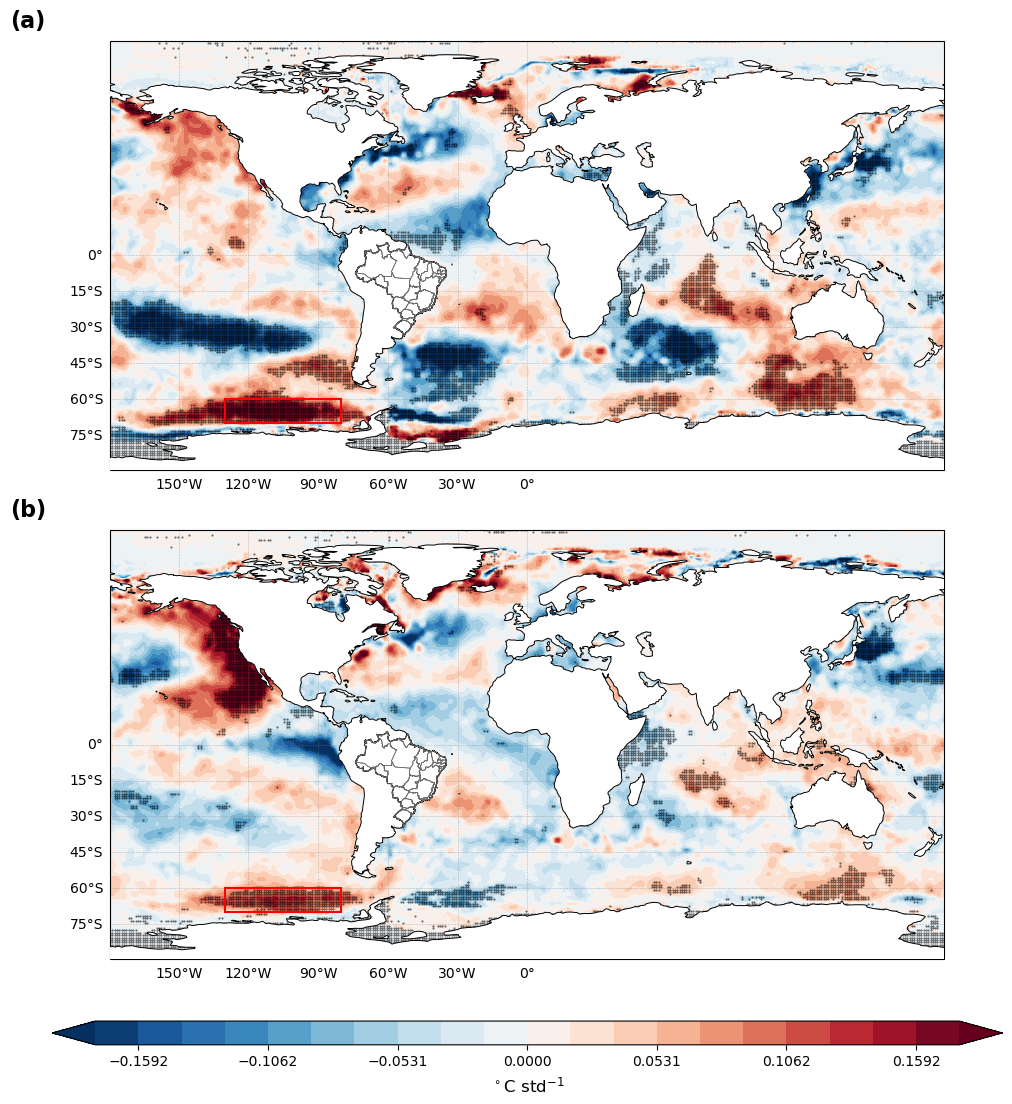

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
import xarray as xr


# =========================
# 读取巴西边界与州界
# =========================
Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)

BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")
BRA_shp.rename(columns={'NAME_1': 'loc'}, inplace=True)


def plot_one_panel(
    ax,
    reg,
    pv_thres=0.1,
    vabs=None,
    cmap='RdBu_r',
    draw_sig=True
):
    slope = reg['slope']
    pv = reg['pv']

    lon = slope.lon.values
    lat = slope.lat.values
    slope2d = slope.values
    pv2d = pv.values

    if vabs is None:
        vabs = np.nanquantile(np.abs(slope2d), 0.98)

    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = np.nanmax(np.abs(slope2d))

    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = 1e-6

    Lon, Lat = np.meshgrid(lon, lat)
    data_crs = ccrs.PlateCarree()

    # 图幅范围：左界 150W，右界 0，南界 75S，北界 0


    levels = np.linspace(-vabs, vabs, 21)
    cf = ax.contourf(
        Lon, Lat, slope2d,
        levels=levels,
        cmap=cmap,
        extend='both',
        transform=data_crs,
        zorder=1
    )

    if draw_sig:
        sig = np.isfinite(slope2d) & np.isfinite(pv2d) & (pv2d < pv_thres)
        ax.scatter(
            Lon[sig], Lat[sig],
            s=0.25,
            color='k',
            alpha=0.6,
            transform=data_crs,
            zorder=3
        )

    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='black', zorder=5)

    # 巴西国界线
    BRA_shp.boundary.plot(
        ax=ax,
        transform=data_crs,
        color='black',
        linewidth=0.8,
        zorder=6
    )

    # 巴西州界线
    Brazil.boundary.plot(
        ax=ax,
        transform=data_crs,
        color='dimgray',
        linewidth=0.5,
        zorder=7
    )

    # 红色空心框：130W–80W, 70S–60S
    rect = mpatches.Rectangle(
        xy=(-130, -70),
        width=50,
        height=10,
        fill=False,
        edgecolor='red',
        linewidth=1.5,
        transform=data_crs,
        zorder=8
    )
    ax.add_patch(rect)

    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.4,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = FixedLocator(np.arange(-150, 1, 30))
    gl.ylocator = FixedLocator(np.arange(-75, 1, 15))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    return cf


def plot_two_panels_vertical(
    reg1,
    reg2,
    savepath=None,
    pv_thres=0.1,
    cmap='RdBu_r'
):
    proj = ccrs.PlateCarree()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 12),
        subplot_kw={'projection': proj}
    )

    fig.subplots_adjust(left=0.10, right=0.98, top=0.97, bottom=0.11, hspace=0.14)

    vabs1 = np.nanquantile(np.abs(reg1['slope'].values), 0.98)
    vabs2 = np.nanquantile(np.abs(reg2['slope'].values), 0.98)
    vabs = np.nanmax([vabs1, vabs2])
    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = 1e-6

    cf1 = plot_one_panel(
        axes[0], reg1,
        pv_thres=pv_thres,
        vabs=vabs,
        cmap=cmap,
        draw_sig=True
    )

    cf2 = plot_one_panel(
        axes[1], reg2,
        pv_thres=pv_thres,
        vabs=vabs,
        cmap=cmap,
        draw_sig=True
    )

    # (a)(b) 放在子图外左上方
    axes[0].text(
        -0.12, 1.02, '(a)',
        transform=axes[0].transAxes,
        fontsize=16,
        fontweight='bold',
        ha='left',
        va='bottom'
    )
    axes[1].text(
        -0.12, 1.02, '(b)',
        transform=axes[1].transAxes,
        fontsize=16,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

    # 下侧水平 colorbar
    # 下侧水平 colorbar
    cbar = fig.colorbar(
    cf2,
    ax=axes,
    orientation='horizontal',
    pad=0.06,
    fraction=0.05,
    aspect=40,
    shrink=0.9
    )
    cbar.set_label(r'$^\circ$C std$^{-1}$', fontsize=12)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()


# =========================
# 调用示例
# =========================
plot_two_panels_vertical(
    reg1=sst_JFM_AD_NDJ,
    reg2=sst_AMJ_AD_NDJ,
    savepath="/Volumes/limenghan/巴西玉米/南极偶极子与环流/Regression_of_SST_AD_NDJ_two_panels.png",
    pv_thres=0.1,
    cmap='RdBu_r'
)

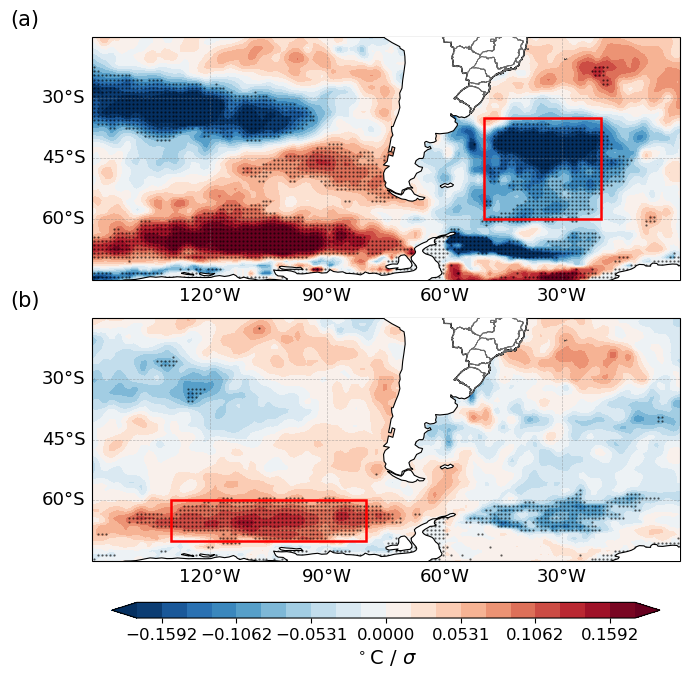

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
import xarray as xr


# =========================
# 读取巴西边界与州界
# =========================
Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)

BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")
BRA_shp.rename(columns={'NAME_1': 'loc'}, inplace=True)


def plot_one_panel(
    ax,
    reg,
    pv_thres=0.1,
    vabs=None,
    cmap='RdBu_r',
    draw_sig=True,
    box=None,                 # 新增：每个子图单独传入红框
    box_color='red',
    box_linewidth=1.8
):
    slope = reg['slope']
    pv = reg['pv']

    lon = slope.lon.values
    lat = slope.lat.values
    slope2d = slope.values
    pv2d = pv.values

    if vabs is None:
        vabs = np.nanquantile(np.abs(slope2d), 0.98)

    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = np.nanmax(np.abs(slope2d))

    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = 1e-6

    Lon, Lat = np.meshgrid(lon, lat)
    data_crs = ccrs.PlateCarree()

    # 图幅范围：左界 150W，右界 0，南界 75S，北界 15S
    ax.set_extent([-150, 0, -75, -15], crs=data_crs)

    levels = np.linspace(-vabs, vabs, 21)
    cf = ax.contourf(
        Lon, Lat, slope2d,
        levels=levels,
        cmap=cmap,
        extend='both',
        transform=data_crs,
        zorder=1
    )

    if draw_sig:
        sig = np.isfinite(slope2d) & np.isfinite(pv2d) & (pv2d < pv_thres)
        ax.scatter(
            Lon[sig], Lat[sig],
            s=0.35,
            color='k',
            alpha=0.6,
            transform=data_crs,
            zorder=3
        )

    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=5)

    # 巴西国界线
    BRA_shp.boundary.plot(
        ax=ax,
        transform=data_crs,
        color='black',
        linewidth=0.9,
        zorder=6
    )

    # 巴西州界线
    Brazil.boundary.plot(
        ax=ax,
        transform=data_crs,
        color='dimgray',
        linewidth=0.6,
        zorder=7
    )

    # =========================
    # 红框（支持每个子图不同）
    # box = (lon1, lon2, lat1, lat2)
    # =========================
    if box is not None:
        lon1, lon2, lat1, lat2 = box
        rect = mpatches.Rectangle(
            xy=(lon1, lat1),
            width=(lon2 - lon1),
            height=(lat2 - lat1),
            fill=False,
            edgecolor=box_color,
            linewidth=box_linewidth,
            transform=data_crs,
            zorder=8
        )
        ax.add_patch(rect)

    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = FixedLocator(np.arange(-150, 1, 30))
    gl.ylocator = FixedLocator(np.arange(-75, 1, 15))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

    return cf


def plot_two_panels_vertical(
    reg1,
    reg2,
    savepath=None,
    pv_thres=0.1,
    cmap='RdBu_r'
):
    proj = ccrs.PlateCarree()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(7, 7),
        subplot_kw={'projection': proj}
    )

    fig.subplots_adjust(left=0.11, right=0.98, top=0.97, bottom=0.12, hspace=0.16)

    vabs1 = np.nanquantile(np.abs(reg1['slope'].values), 0.98)
    vabs2 = np.nanquantile(np.abs(reg2['slope'].values), 0.98)
    vabs = np.nanmax([vabs1, vabs2])
    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = 1e-6

    # 图 a 红框：35S–60S, 50W–20W
    cf1 = plot_one_panel(
        axes[0], reg1,
        pv_thres=pv_thres,
        vabs=vabs,
        cmap=cmap,
        draw_sig=True,
        box=(-50, -20, -60, -35)
    )

    # 图 b 红框：70S–60S, 130W–80W
    cf2 = plot_one_panel(
        axes[1], reg2,
        pv_thres=pv_thres,
        vabs=vabs,
        cmap=cmap,
        draw_sig=True,
        box=(-130, -80, -70, -60)
    )

    # (a)(b) 放在子图外左上方
    axes[0].text(
        -0.14, 1.03, '(a)',
        transform=axes[0].transAxes,
        fontsize=15,
        ha='left',
        va='bottom'
    )
    axes[1].text(
        -0.14, 1.03, '(b)',
        transform=axes[1].transAxes,
        fontsize=15,
        ha='left',
        va='bottom'
    )

    # 下侧水平 colorbar
    cbar = fig.colorbar(
        cf2,
        ax=axes,
        orientation='horizontal',
        pad=0.07,
        fraction=0.05,
        aspect=35,
        shrink=0.9
    )
    cbar.set_label(r'$^\circ$C / $\sigma$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()


# =========================
# 调用示例
# =========================
plot_two_panels_vertical(
    reg1=sst_JFM_AD_NDJ,
    reg2=sst_AMJ_AD_NDJ,
    savepath="/Volumes/limenghan/巴西玉米/论文图/Figure5_Regression_of_SST_AD_NDJ_two_panels.png",
    pv_thres=0.1,
    cmap='RdBu_r'
)

In [141]:
# 1. 选取区域：130W–80W, 70S–60S
swpa_region_JFM = sst_JFM_nosig.sel(
    lon=slice(-130, -80),
    lat=slice(-70,-60)
)
swpa_region_AMJ = sst_AMJ_nosig.sel(
    lon=slice(-130, -80),
    lat=slice(-70,-60)
)
# 2. 计算纬度加权区域平均
weights_JFM = np.cos(np.deg2rad(swpa_region_JFM['lat']))
weights_AMJ = np.cos(np.deg2rad(swpa_region_AMJ['lat']))
SWPA_JFM =swpa_region_JFM.weighted(weights_JFM).mean(dim=['lat', 'lon'])
SWPA_AMJ =swpa_region_AMJ.weighted(weights_AMJ).mean(dim=['lat', 'lon'])
# 3. 标准化
SWPA_std_JFM = (SWPA_JFM - SWPA_JFM.mean(dim='season_year')) / SWPA_JFM.std(dim='season_year')
SWPA_std_AMJ = (SWPA_AMJ - SWPA_AMJ.mean(dim='season_year')) / SWPA_AMJ.std(dim='season_year')

# 4. 改名
SWPA_JFM= SWPA_std_JFM.rename('SWPA_std_JFM')
SWPA_AMJ= SWPA_std_AMJ.rename('SWPA_std_AMJ')

In [152]:
# 1. 选取 JFM 时期南大西洋区域：50W–20W, 60S–35S
swa_region_JFM = sst_JFM_nosig.sel(
    lon=slice(-50, -20),
    lat=slice(-60, -35)
)

# 2. 计算纬度加权区域平均
weights_JFM = np.cos(np.deg2rad(swa_region_JFM['lat']))
SWA_JFM = swa_region_JFM.weighted(weights_JFM).mean(dim=['lat', 'lon'])


# 3. 标准化
SWA_std_JFM = (
    SWA_JFM - SWA_JFM.mean(dim='season_year')
) / SWA_JFM.std(dim='season_year')

# 4. 改名
SWA_JFM = SWA_std_JFM.rename('SWA_std_JFM')

# 5. 转成 pandas Series
JFM_SWA = SWA_JFM.to_series()

In [142]:

JFM_series = SWPA_JFM.to_series()
AMJ_series = SWPA_AMJ.to_series()

print(JFM_series)
print(AMJ_series)

season_year
1981.0    0.388688
1982.0   -0.541281
1983.0    0.094090
1984.0   -0.563758
1985.0    1.035283
1986.0   -1.616995
1987.0   -1.104455
1988.0    0.670962
1989.0    2.637036
1990.0   -0.126126
1991.0   -2.229441
1992.0    1.234604
1993.0    1.358774
1994.0    0.712077
1995.0    0.569296
1996.0   -1.148091
1997.0   -0.525713
1998.0    0.473279
1999.0   -0.777223
2000.0   -1.105871
2001.0   -0.444560
2002.0   -1.006911
2003.0    1.215906
2004.0    0.025088
2005.0    0.323864
2006.0    1.233004
2007.0   -0.413690
2008.0    1.077437
2009.0    0.076116
2010.0    0.397772
2011.0   -0.694674
2012.0   -0.232166
2013.0    1.325244
2014.0   -1.039648
2015.0   -0.434758
2016.0   -0.843161
Name: SWPA_std_JFM, dtype: float64
season_year
1981.0    0.537267
1982.0   -1.337479
1983.0    0.713975
1984.0   -0.357808
1985.0    0.302475
1986.0   -1.506683
1987.0   -1.913356
1988.0    0.564580
1989.0    1.715240
1990.0   -0.464850
1991.0   -1.225848
1992.0    2.395363
1993.0    1.201906
1994.0    

In [128]:
AD_NDJ_1_mean_std

year
1980    0.588371
1981   -0.102739
1982   -0.904108
1983    0.261572
1984    0.766755
1985    0.041002
1986   -0.607759
1987   -0.723235
1988    1.748914
1989   -0.141903
1990   -1.128484
1991    0.871293
1992   -0.320225
1993    0.613111
1994    0.436773
1995    0.343788
1996   -1.193794
1997    0.294784
1998   -2.231587
1999   -1.347054
2000    0.643514
2001   -2.044951
2002    2.115305
2003    1.007260
2004   -0.222683
2005    0.115587
2006   -1.299055
2007    0.647437
2008   -0.279629
2009   -0.237439
2010   -1.258600
2011    1.424559
2012    0.938097
2013    1.079903
2014   -0.035405
2015    0.140624
dtype: float64

In [48]:
import numpy as np
import pandas as pd
import xarray as xr

def reg_location_bootstrap_like_reg_location(
    x_data,
    y_data,
    n_boot=2000,
    seed=0,
    return_ci=True,
):
    """
    与 reg_location 相同的对齐方式（DataFrame {'x':x_data,'y':y_point.values} + dropna），
    只是把 p-value 改为 bootstrap 双侧检验。

    返回：Dataset(slope, pv, n, [ci_low, ci_high])
    """
    # 1) 标准化 y（与 reg_location 一致：ddof=0）
    y_data = (y_data - y_data.mean(dim="season_year")) / y_data.std(dim="season_year")
    y = y_data

    slope = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
    pval  = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
    n_eff = np.zeros((len(y.lat), len(y.lon)), dtype=int)

    if return_ci:
        ci_low  = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)
        ci_high = np.full((len(y.lat), len(y.lon)), np.nan, dtype=float)

    rng = np.random.default_rng(seed)

    # 转成 numpy/Series 都行，DataFrame 构造时保持原样（以完全复刻你的对齐逻辑）
    x_in = x_data

    for alon in range(len(y.lon)):
        for alat in range(len(y.lat)):
            # 取格点时间序列（与你原函数一致：sel -> to_series -> values）
            y_point = y_data.sel(lat=y_data.lat[alat], lon=y_data.lon[alon])
            if isinstance(y_point, xr.DataArray):
                y_point = y_point.to_series()
            y_point = y_point.values  # 丢掉索引（与你一致）

            # 关键：对齐方式完全复刻你的 merged_df 写法
            merged_df = pd.DataFrame({"x": x_in, "y": y_point}).dropna()

            n = len(merged_df)
            n_eff[alat, alon] = n
            if n <= 1:
                continue

            xv = merged_df["x"].to_numpy(dtype=float)
            yv = merged_df["y"].to_numpy(dtype=float)

            # 点估计斜率（用快速公式）
            x_center = xv - xv.mean()
            denom = np.sum(x_center**2)
            if denom == 0:
                continue
            beta_hat = np.sum(x_center * (yv - yv.mean())) / denom
            slope[alat, alon] = beta_hat

            # bootstrap p-value 需要一定样本量更稳定；n<3 时只给 slope，不给 p
            if n < 3:
                continue

            idx = np.arange(n)
            beta_boot = np.empty(n_boot, dtype=float)

            for b in range(n_boot):
                samp = rng.choice(idx, size=n, replace=True)
                xb = xv[samp]
                yb = yv[samp]
                xb_center = xb - xb.mean()
                denom_b = np.sum(xb_center**2)
                if denom_b == 0:
                    beta_boot[b] = np.nan
                else:
                    beta_boot[b] = np.sum(xb_center * (yb - yb.mean())) / denom_b

            beta_boot = beta_boot[np.isfinite(beta_boot)]
            if beta_boot.size < max(50, int(n_boot * 0.2)):
                continue

            # 双侧 bootstrap p-value
            p = (np.sum(np.abs(beta_boot) >= np.abs(beta_hat)) + 1.0) / (beta_boot.size + 1.0)
            pval[alat, alon] = p

            if return_ci:
                ci_low[alat, alon], ci_high[alat, alon] = np.quantile(beta_boot, [0.025, 0.975])

    ds = xr.Dataset(
        {
            "slope": xr.DataArray(slope, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
            "pv":    xr.DataArray(pval,  coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
            "n":     xr.DataArray(n_eff, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon")),
        },
        attrs={"description": "Bootstrap regression (alignment matches reg_location DataFrame+dropna)"},
    )

    if return_ci:
        ds["ci_low"]  = xr.DataArray(ci_low,  coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon"))
        ds["ci_high"] = xr.DataArray(ci_high, coords={"lat": y.lat, "lon": y.lon}, dims=("lat", "lon"))

    return ds


In [49]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import binary_fill_holes, label

def _outer_big_mask(mask2d_bool):
    """填洞 + 只保留最大连通块 -> 外部大框（避免内部小圈/小块）"""
    filled = binary_fill_holes(mask2d_bool)
    lab, nlab = label(filled)
    if nlab <= 1:
        return filled.astype(int)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    big_id = sizes.argmax()
    big = (lab == big_id)
    return big.astype(int)

def plot_cli_slp_(
    data, name, country_gdf, variable_name,
    maize2d=None,                 # ✅ 传入你的 maize2d DataArray
    maize_threshold=0,            # maize2d > 0 认为有玉米（可改）
    maize_pad_deg=0.0,            # 红框外扩（度）
    maize_color="red",
    maize_ls="--",
    maize_lw=2.2,
):

    # 转为 DataArray
    slp_data = xr.DataArray(data['slope'], coords={'lat': data['lat'], 'lon': data['lon']}, dims=('lat', 'lon'))
    slp_data_pv = xr.DataArray(data['pv'], coords={'lat': data['lat'], 'lon': data['lon']}, dims=('lat', 'lon'))

    # ✨ 使用 shapefile 进行裁剪 (只保留巴西区域)
    slp_data = mask_by_geodf(slp_data, country_gdf)
    slp_data_pv = mask_by_geodf(slp_data_pv, country_gdf)

    lon = slp_data["lon"].values
    lat = slp_data["lat"].values

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18, 12))

    # ----- 填色图颜色方案 -----
    if variable_name in ['tmx','tmp','tmn','dtr']:
        cmap, vmin, vmax = 'coolwarm', -0.4, 0.4
    elif variable_name == 'pre':
        cmap, vmin, vmax = 'PRGn', -0.3, 0.3
    elif variable_name in ['evap','vpd']:
        cmap, vmin, vmax = 'PiYG_r', -0.3, 0.3
    elif variable_name == 'msdwswrf':
        cmap, vmin, vmax = 'bwr', -0.3, 0.3
    elif variable_name == 'smroot':
        cmap, vmin, vmax = 'BrBG', -0.36, 0.36
    else:
        cmap, vmin, vmax = 'PuOr', -0.25, 0.25

    contourf = ax.contourf(
        lon, lat, slp_data.values,
        levels=13, cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), extend='both'
    )
    plt.colorbar(contourf, ax=ax, shrink=0.6)

    # ----- 边界 -----
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

    # 坐标轴
    ax.set_xticks([-80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_yticks([-40, -20, 0, 20], crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=10)

    # ----- 显著性填充 -----
    mask = (slp_data_pv.values < 0.1) & np.isfinite(slp_data_pv.values)
    lons, lats = np.meshgrid(lon, lat)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                ax.fill_between([lons[i, j], lons[i, j] + 1],
                                lats[i, j], lats[i, j] + 1,
                                color='none', edgecolor='gray',
                                hatch='///', linewidth=0.1,
                                transform=ccrs.PlateCarree())

    # ✅ ----- 玉米红色虚线外边界（非矩形）-----
    if maize2d is not None:
        # 1) 对齐到当前 slp 网格
        maize2d_al = maize2d.interp_like(slp_data, method="nearest")

        # 2) 裁剪到巴西（可选，但通常好看）
        maize2d_al = mask_by_geodf(maize2d_al, country_gdf)

        # 3) 生成 bool mask（有玉米=1）
        if np.issubdtype(maize2d_al.dtype, np.number):
            m = np.isfinite(maize2d_al.values) & (maize2d_al.values > maize_threshold)
        else:
            m = np.isfinite(maize2d_al.values)

        # 4) 填洞 + 最大连通块（只保留外部大框）
        big = _outer_big_mask(m)

        # 5) 如需外扩 pad_deg：用“坐标扩框”做最稳（不做形态学膨胀，避免像素尺度依赖）
        #    做法：算出 big 的最外接经纬度范围，然后用 contour 画这个范围的 mask 边界会变矩形；
        #    所以这里建议 pad_deg=0；如果你确实要外扩，我再给你像素膨胀版。
        if maize_pad_deg != 0:
            print("⚠️ maize_pad_deg!=0 可能会让边界变形/依赖分辨率；建议先用 0。")

        # 6) 用 contour 画 0.5 等值线作为边界
        ax.contour(
            lon, lat, big,
            levels=[0.5],
            colors=maize_color,
            linestyles=maize_ls,
            linewidths=maize_lw,
            transform=ccrs.PlateCarree(),
            zorder=10
        )

    plt.title(name, fontsize=25)

    # ✨ 自动按 shapefile 设置显示范围 + 向南扩展
    minx, miny, maxx, maxy = country_gdf.total_bounds
    south_extend = 5
    new_miny = miny - south_extend
    ax.set_extent([minx, maxx, new_miny, maxy], crs=ccrs.PlateCarree())

    plt.savefig(f'/Volumes/limenghan/巴西玉米/论文图/Figure6_{name}_new.png', dpi=300)
    plt.show()


In [50]:
# 指定包含所有文件的文件夹路径
folder_path ='/Volumes/limenghan/气象要素/vertically_integrated_moisture_divergence/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
VIMD= xr.open_mfdataset(files, combine='nested', concat_dim='time')
# 如果需要，可以在这里进行进一步的数据处理或操作
# 最后，保存合并后的 Dataset 到一个新的 nc 文件
VIMD= VIMD.rename({'longitude': 'lon'})
VIMD= VIMD.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(VIMD.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(VIMD.lat)/180), int(len(VIMD.lon)/360)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    VIMD= VIMD.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
VIMD

<xarray.Dataset>
Dimensions:  (time: 468, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float32 0.375 1.375 2.375 3.375 ... 356.4 357.4 358.4 359.4
  * lat      (lat) float32 89.62 88.62 87.62 86.62 ... -87.38 -88.38 -89.38
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2017-12-01
Data variables:
    vimd     (time, lat, lon) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-11-14 06:02:28 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [51]:
# 指定包含所有文件的文件夹路径
folder_path ='/Volumes/limenghan/气象要素/vertical_integral_of_eastward_water_vapour_flux/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
Qu= xr.open_mfdataset(files, combine='nested', concat_dim='time')
# 如果需要，可以在这里进行进一步的数据处理或操作
# 最后，保存合并后的 Dataset 到一个新的 nc 文件
Qu= Qu.rename({'longitude': 'lon'})
Qu= Qu.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(Qu.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(Qu.lat)/180), int(len(Qu.lon)/360)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    Qu= Qu.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
Qu

<xarray.Dataset>
Dimensions:  (time: 468, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float32 0.375 1.375 2.375 3.375 ... 356.4 357.4 358.4 359.4
  * lat      (lat) float32 89.62 88.62 87.62 86.62 ... -87.38 -88.38 -89.38
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2017-12-01
Data variables:
    p71.162  (time, lat, lon) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-11-12 03:31:38 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [52]:
# 指定包含所有文件的文件夹路径
folder_path ='/Volumes/limenghan/气象要素/vertical_integral_of_northward_water_vapour_flux/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
Qv= xr.open_mfdataset(files, combine='nested', concat_dim='time')
# 如果需要，可以在这里进行进一步的数据处理或操作
# 最后，保存合并后的 Dataset 到一个新的 nc 文件
Qv= Qv.rename({'longitude': 'lon'})
Qv= Qv.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(Qv.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(Qv.lat)/180), int(len(Qv.lon)/360)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    Qv= Qv.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
Qv

<xarray.Dataset>
Dimensions:  (time: 492, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float32 0.375 1.375 2.375 3.375 ... 356.4 357.4 358.4 359.4
  * lat      (lat) float32 89.62 88.62 87.62 86.62 ... -87.38 -88.38 -89.38
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Data variables:
    p72.162  (time, lat, lon) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-11-13 08:30:47 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [53]:
# 指定包含所有文件的文件夹路径
folder_path ='/Volumes/limenghan/气象要素/vertical_velocity/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
w= xr.open_mfdataset(files, combine='nested', concat_dim='time')
# 如果需要，可以在这里进行进一步的数据处理或操作
# 最后，保存合并后的 Dataset 到一个新的 nc 文件
w= w.rename({'longitude': 'lon'})
w= w.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(w.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(w.lat)/180), int(len(w.lon)/360)  # 2° x 2° 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    w= w.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
w

<xarray.Dataset>
Dimensions:  (time: 492, level: 37, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float32 0.375 1.375 2.375 3.375 ... 356.4 357.4 358.4 359.4
  * lat      (lat) float32 89.62 88.62 87.62 86.62 ... -87.38 -88.38 -89.38
  * level    (level) int32 1 2 3 5 7 10 20 30 ... 850 875 900 925 950 975 1000
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Data variables:
    w        (time, level, lat, lon) float32 dask.array<chunksize=(1, 37, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2023-09-26 11:00:05 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [54]:
#水汽
##处理气象要素数据
##1980到2017，三月滑动平均
##先去趋势
vimd=VIMD['vimd']
qu=Qu['p71.162']
qv=Qv['p72.162']
w=w.sel(level=700)['w']
qu=time_sel(qu,1980,2020)
qv=time_sel(qv,1980,2020)
w=time_sel(w,1980,2020)
vimd=time_sel(vimd,1980,2020)
qu=detrend_weather(qu)
qv=detrend_weather(qv)
w=detrend_weather(w)
vimd=detrend_weather(vimd)
qu=time_sel(qu,1980,2020)
qv=time_sel(qv,1980,2020)
w=time_sel(w,1980,2020)
vimd=time_sel(vimd,1980,2020)

In [61]:
water_varible=['vimd','qu','qv','w']
for i in water_varible:
    locals()[f'{i}_sort']=locals()[f'{i}'].sortby(['lat', 'lon'])

In [57]:
for variable in water_varible:
    locals()[f'{variable}_JFM']=calculate_seasonal_mean(locals()[f'{variable}_sort'], 1, 3, 1981, 2016)
    locals()[f'{variable}_AMJ']=calculate_seasonal_mean(locals()[f'{variable}_sort'], 4,6, 1981, 2016)
    locals()[f'{variable}_AMJ_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_AMJ'], nino_AMJ, iob_AMJ, dim="season_year")
    locals()[f'{variable}_JFM_nosig']=remove_nino_iob_from_da(locals()[f'{variable}_JFM'], nino_JFM, iob_JFM, dim="season_year")

In [146]:
for i in water_varible:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SWPA_{time}']=reg_location_global(locals()[f'{time}_series'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SWPA_{time}')

已计算vimd_JFM_SWPA_JFM
已计算vimd_AMJ_SWPA_AMJ
已计算qu_JFM_SWPA_JFM
已计算qu_AMJ_SWPA_AMJ
已计算qv_JFM_SWPA_JFM
已计算qv_AMJ_SWPA_AMJ
已计算w_JFM_SWPA_JFM
已计算w_AMJ_SWPA_AMJ


In [153]:
for i in [vimd,w]:
    for time in ['JFM']:
        locals()[f'{i}_{time}_SWA_{time}']=reg_location_global(locals()[f'{time}_SWA'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SWA_{time}')

已计算vimd_JFM_SWA_JFM
已计算qu_JFM_SWA_JFM
已计算qv_JFM_SWA_JFM
已计算w_JFM_SWA_JFM


In [69]:
JFM_SWA

['dtr', 'cld', 'pre', 'vpd', 'evap', 'msdwswrf', 'smroot', 'vap']

In [147]:
for i in ['dtr', 'cld', 'pre', 'msdwswrf', 'smroot']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SWPA_{time}']=reg_location_bootstrap_like_reg_location(locals()[f'{time}_series'],locals()[f'{i}_{time}_nosig'],
            n_boot=1000,
            seed=0,
            return_ci=True,)
        print(f'已计算{i}_{time}_SWPA_{time}')

已计算dtr_JFM_SWPA_JFM
已计算dtr_AMJ_SWPA_AMJ
已计算cld_JFM_SWPA_JFM
已计算cld_AMJ_SWPA_AMJ
已计算pre_JFM_SWPA_JFM
已计算pre_AMJ_SWPA_AMJ
已计算msdwswrf_JFM_SWPA_JFM
已计算msdwswrf_AMJ_SWPA_AMJ
已计算smroot_JFM_SWPA_JFM
已计算smroot_AMJ_SWPA_AMJ


In [154]:
for i in ['dtr', 'cld', 'pre', 'msdwswrf', 'smroot']:
    for time in ['JFM']:
        locals()[f'{i}_{time}_SWA_{time}']=reg_location_bootstrap_like_reg_location(locals()[f'{time}_SWA'],locals()[f'{i}_{time}_nosig'],
            n_boot=1000,
            seed=0,
            return_ci=True,)
        print(f'已计算{i}_{time}_SWA_{time}')
#for i in ['hgt200','hgt500','hgt850','slp']:
for i in ['hgt200','sst','sic','vwnd850','uwnd850']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SWPA_{time}']=reg_location_global(locals()[f'{time}_series'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SWPA_{time}')

已计算dtr_JFM_SWA_JFM
已计算cld_JFM_SWA_JFM
已计算pre_JFM_SWA_JFM
已计算msdwswrf_JFM_SWA_JFM
已计算smroot_JFM_SWA_JFM


已计算hgt200_JFM_SWPA_JFM
已计算hgt200_AMJ_SWPA_AMJ
已计算sst_JFM_SWPA_JFM
已计算sst_AMJ_SWPA_AMJ
已计算sic_JFM_SWPA_JFM
已计算sic_AMJ_SWPA_AMJ
已计算vwnd850_JFM_SWPA_JFM
已计算vwnd850_AMJ_SWPA_AMJ
已计算uwnd850_JFM_SWPA_JFM
已计算uwnd850_AMJ_SWPA_AMJ


In [155]:
#for i in ['hgt200','hgt500','hgt850','slp']:
for i in ['hgt200','sst','vwnd850','uwnd850']:
    for time in ['JFM']:
        locals()[f'{i}_{time}_SWA_{time}']=reg_location_global(locals()[f'{time}_SWA'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SWA_{time}')

已计算hgt200_JFM_SWA_JFM
已计算sst_JFM_SWA_JFM
已计算vwnd850_JFM_SWA_JFM
已计算uwnd850_JFM_SWA_JFM


In [210]:
# ============================================================
# ✅ 完整绘图代码（再次更新）：
#    HGT(填色, 位势->位势高度) + 风矢量(U/V箭头)
#    - 海洋白色背景；✅ 陆地也填色（不盖 LAND）
#    - ✅ 玉米边界：红色虚线，只保留外部大框（填洞+最大连通块）
#    - ✅ 叠加巴西“州界线”：传入 GeoDataFrame Brazil（只画边界线）
#    - 自动把 0–360 经度数据转到 -180–180（适配 uwnd/vwnd）
#    - 右上角 quiverkey 标 1 m/s
#    - 可选 pv<=0.1 才填色（否则白色），或 pv_max=None 不做显著性遮罩
#    - 经度接缝白线：对填色场/边界加 cyclic point
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from scipy.ndimage import binary_fill_holes, label

G0 = 9.80665  # m/s^2

def trans_lon(ds):
    lon_name = 'lon'
    ds = ds.copy()
    ds['longitude_adjusted'] = xr.where(ds[lon_name] > 180, ds[lon_name] - 360, ds[lon_name])
    ds = (
        ds.swap_dims({lon_name: 'longitude_adjusted'})
          .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted.values)})
          .drop(lon_name)
    )
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds

def _ensure_lon180(obj):
    if isinstance(obj, xr.Dataset):
        if "lon" in obj.coords and obj.sizes.get("lon", 0) > 0 and float(obj.lon.max()) > 180:
            return trans_lon(obj)
        return obj
    da = obj
    if "lon" in da.coords and da.sizes.get("lon", 0) > 0 and float(da.lon.max()) > 180:
        lon_adj = xr.where(da["lon"] > 180, da["lon"] - 360, da["lon"])
        da = da.assign_coords(lon=lon_adj).sortby("lon")
    return da

def _as_da(obj, varname="slope"):
    if isinstance(obj, xr.Dataset):
        if varname not in obj:
            raise KeyError(f"Dataset 不包含 '{varname}'，可用变量：{list(obj.data_vars)}")
        return obj[varname]
    return obj

def _slice_coord(da, coord, v0, v1):
    if coord not in da.coords or da.sizes.get(coord, 0) == 0:
        return da
    c = da[coord].values
    if c[0] < c[-1]:
        return da.sel({coord: slice(v0, v1)})
    else:
        return da.sel({coord: slice(v1, v0)})

def _crop_box(da, lon0, lon1, lat0, lat1):
    da = _slice_coord(da, "lon", lon0, lon1)
    da = _slice_coord(da, "lat", lat0, lat1)
    return da

def _add_cyclic(z2d, lon1d):
    z_cyc, lon_cyc = add_cyclic_point(z2d, coord=lon1d)
    return z_cyc, lon_cyc

def _outer_big_mask(mask2d_bool):
    """填洞 + 只保留最大连通块 -> 外部大框"""
    filled = binary_fill_holes(mask2d_bool)
    lab, nlab = label(filled)
    if nlab <= 1:
        return filled.astype(int)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    big_id = sizes.argmax()
    big = (lab == big_id)
    return big.astype(int)

from cartopy.util import add_cyclic_point
from scipy.ndimage import binary_fill_holes, label

SEC_PER_DAY = 86400.0

# =============================
# 1) 经度统一到 0–360
# =============================
def _to_lon360(obj):
    """把 lon 转为 0–360 并排序；支持 DataArray / Dataset"""
    if isinstance(obj, xr.Dataset):
        if "lon" not in obj.coords:
            return obj
        lon = obj["lon"].values
        if np.nanmin(lon) < 0:
            lon360 = (obj["lon"] % 360)
            obj = obj.assign_coords(lon=lon360).sortby("lon")
        return obj
    da = obj
    if "lon" not in da.coords:
        return da
    lon = da["lon"].values
    if np.nanmin(lon) < 0:
        lon360 = (da["lon"] % 360)
        da = da.assign_coords(lon=lon360).sortby("lon")
    return da

def _as_da(obj, varname="slope"):
    if isinstance(obj, xr.Dataset):
        if varname not in obj:
            raise KeyError(f"Dataset 不包含 '{varname}'，可用变量：{list(obj.data_vars)}")
        return obj[varname]
    return obj

def _slice_coord(da, coord, v0, v1):
    if coord not in da.coords or da.sizes.get(coord, 0) == 0:
        return da
    c = da[coord].values
    if c[0] < c[-1]:
        return da.sel({coord: slice(v0, v1)})
    else:
        return da.sel({coord: slice(v1, v0)})

def _crop_box(da, lon0, lon1, lat0, lat1):
    da = _slice_coord(da, "lon", lon0, lon1)
    da = _slice_coord(da, "lat", lat0, lat1)
    return da

def _add_cyclic(z2d, lon1d):
    z_cyc, lon_cyc = add_cyclic_point(z2d, coord=lon1d)
    return z_cyc, lon_cyc

def _largest_component_mask(mask_bool):
    """填洞 + 最大连通块（确保只画外轮廓）"""
    filled = binary_fill_holes(mask_bool)
    lab, nlab = label(filled)
    if nlab < 1:
        return None
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    big_id = sizes.argmax()
    return (lab == big_id)

def _brazil_bounds_to_360(Brazil, pad_deg=2.0):
    """
    Brazil.total_bounds 是 [-180,180] 逻辑；转成 0–360 再返回 extent
    返回 lon0, lon1, lat0, lat1 （lon0<lon1，且都在0–360）
    """
    minx, miny, maxx, maxy = Brazil.total_bounds  # 经常是负经度

    # 转 0–360
    minx360 = minx % 360
    maxx360 = maxx % 360

    # Brazil 在西半球：例如 [-74, -34] -> [286, 326]
    # 一般会满足 minx360 < maxx360
    lon0 = minx360 - pad_deg
    lon1 = maxx360 + pad_deg

    # 防止越界
    lon0 = lon0 % 360
    lon1 = lon1 % 360

    # 如果因为 pad 导致 lon0 > lon1（跨 0 度缝），我们选择“不要跨缝”，直接拉到 0–360内合理范围
    # 对巴西这种情况通常不会跨缝；这里做个兜底：
    if lon0 > lon1:
        # 让范围覆盖 [lon0,360) U [0,lon1] 会很麻烦；巴西一般不会出现
        # 简单处理：把 lon0 设为 0，lon1 设为 360（全经度）
        lon0, lon1 = 0.0, 360.0

    lat0 = miny - pad_deg
    lat1 = maxy + pad_deg
    return lon0, lon1, lat0, lat1

# =============================
# 2) VIMFC + omega
# =============================


from scipy.ndimage import binary_fill_holes, label

def _outer_big_mask(mask2d_bool):
    """填洞 + 只保留最大连通块 -> 外部大框（避免内部小圈/小块）"""
    filled = binary_fill_holes(mask2d_bool)
    lab, nlab = label(filled)
    if nlab <= 1:
        return filled.astype(int)
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    big_id = sizes.argmax()
    big = (lab == big_id)
    return big.astype(int)



In [115]:
def _get_maize_extent(maize2d, pad_lon=2.0, pad_lat=2.0):
    """
    根据 maize2d 有效值区域得到绘图范围
    返回: [lon_min, lon_max, lat_min, lat_max]
    """
    lon0, lon1, lat0, lat1 = _get_valid_box_from_dataarray(maize2d)
    return [lon0 - pad_lon, lon1 + pad_lon, lat0 - pad_lat, lat1 + pad_lat]

In [168]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# 你已有这些函数/对象：
# _ensure_lon180, _to_lon360, _as_da, _crop_box, _add_cyclic
# mask_by_geodf
# Brazil, BRA_shp


def _get_valid_box_from_dataarray(da):
    """
    根据 DataArray 中有效值区域获取外接框。
    若全场都有效，则返回 lon/lat 全范围。
    返回:
        lon_min, lon_max, lat_min, lat_max
    """
    if 'lon' not in da.coords or 'lat' not in da.coords:
        raise ValueError("maize2d 必须包含 lon 和 lat 坐标")

    lon = da['lon'].values
    lat = da['lat'].values
    val = da.values

    # 只看有限值区域
    mask = np.isfinite(val)

    # 若没有有效值，退化为全范围
    if mask.sum() == 0:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

    # 情况1：经纬度是一维
    if da['lon'].ndim == 1 and da['lat'].ndim == 1:
        if val.ndim != 2:
            # 如果不是二维，直接返回全范围
            return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

        lat_has = np.any(mask, axis=1)
        lon_has = np.any(mask, axis=0)

        lat_sel = lat[lat_has]
        lon_sel = lon[lon_has]

        return (
            float(np.nanmin(lon_sel)),
            float(np.nanmax(lon_sel)),
            float(np.nanmin(lat_sel)),
            float(np.nanmax(lat_sel))
        )

    # 情况2：经纬度是二维
    elif da['lon'].ndim == 2 and da['lat'].ndim == 2:
        lon2 = da['lon'].values
        lat2 = da['lat'].values
        return (
            float(np.nanmin(lon2[mask])),
            float(np.nanmax(lon2[mask])),
            float(np.nanmin(lat2[mask])),
            float(np.nanmax(lat2[mask]))
        )

    # 其他情况，回退到全范围
    else:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))


def _add_maize_box(ax, maize2d, color='red', lw=1.6, ls='--'):
    """
    在图上添加 maize2d 有效值区域的外接虚线框
    """
    if maize2d is None:
        return

    pc = ccrs.PlateCarree()
    lon0, lon1, lat0, lat1 = _get_valid_box_from_dataarray(maize2d)

    rect = mpatches.Rectangle(
        xy=(lon0, lat0),
        width=lon1 - lon0,
        height=lat1 - lat0,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        linestyle=ls,
        transform=pc,
        zorder=20
    )
    ax.add_patch(rect)


def _plot_hgt_panel(
    ax, hgt, u, v,
    Brazil=None,
    maize2d=None,
    extent=(-150, -30, -75, 15),
    pv_max=None,
    cmap="RdBu_r",
    hgt_levels=None,
    wind_step=3,
    wind_scale=None,
    quiver_key_speed=1.0,
    title=None,
    title_fontsize=15,
    label_fontsize=13,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    hgt = _ensure_lon180(hgt)
    u   = _ensure_lon180(u)
    v   = _ensure_lon180(v)

    hgt_da = _as_da(hgt, "slope")
    u_da   = _as_da(u, "slope")
    v_da   = _as_da(v, "slope")

    pv_da = None
    if pv_max is not None:
        if isinstance(hgt, xr.Dataset) and ("pv" in hgt):
            pv_da = hgt["pv"]
        else:
            raise ValueError("pv_max 不为 None 时，需要 hgt 是包含 'pv' 的 xr.Dataset")

    lon0, lon1, lat0, lat1 = extent
    hgt_da = _crop_box(hgt_da, lon0, lon1, lat0, lat1)
    u_da   = _crop_box(u_da,   lon0, lon1, lat0, lat1)
    v_da   = _crop_box(v_da,   lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    u_da = u_da.interp_like(hgt_da, method="linear")
    v_da = v_da.interp_like(hgt_da, method="linear")

    G0 = 9.80665
    hgt_da = hgt_da / G0

    if pv_da is not None:
        pv_da = pv_da.interp_like(hgt_da, method="nearest")
        hgt_da = hgt_da.where(pv_da <= pv_max)

    if hgt_levels is None:
        a = float(np.nanpercentile(np.abs(hgt_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        hgt_levels = np.linspace(-a, a, 13)

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = hgt_da["lon"].values
    lat = hgt_da["lat"].values
    z_cyc, lon_cyc = _add_cyclic(hgt_da.values, lon)

    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=hgt_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    step = int(max(1, wind_step))
    uu = u_da.values[::step, ::step]
    vv = v_da.values[::step, ::step]
    LON, LAT = np.meshgrid(hgt_da["lon"].values, hgt_da["lat"].values)

    q = ax.quiver(
        LON[::step, ::step], LAT[::step, ::step],
        uu, vv,
        transform=pc,
        zorder=6,
        scale=wind_scale,
        scale_units="inches",
        angles="uv",
        width=0.0024,
        headwidth=3.8, headlength=4.8, headaxislength=4.2
    )
    ax.quiverkey(
        q, X=0.90, Y=1.03, U=quiver_key_speed,
        label=f"{quiver_key_speed:g} m/s",
        labelpos="E", coordinates="axes",
        fontproperties={"size": label_fontsize}
    )

    if Brazil is not None:
        try:
            Brazil.boundary.plot(
                ax=ax, transform=pc,
                edgecolor="black", linewidth=0.8, zorder=9
            )
        except TypeError:
            ax.add_geometries(
                Brazil.boundary.geometry, crs=pc,
                edgecolor="black", facecolor="none",
                linewidth=0.8, zorder=9
            )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=0.8, zorder=10)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.7, zorder=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r"m/$\sigma$", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _plot_vimd_panel(
    ax, vimd, omega, Brazil,
    maize2d=None,
    pad_deg=2.0,
    pv_max=None,
    cmap="RdBu_r",
    vimfc_levels=None,
    omega_nlevels=6,
    omega_lw=1.4,
    omega_label=False,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    if hasattr(Brazil, "crs") and (Brazil.crs is not None) and ("4326" not in str(Brazil.crs)):
        Brazil = Brazil.to_crs("EPSG:4326")

    vimd  = _to_lon360(vimd)
    omega = _to_lon360(omega)

    vimd_da  = _as_da(vimd, "slope")
    omega_da = _as_da(omega, "slope") if isinstance(omega, xr.Dataset) else omega

    pv_da = None
    if pv_max is not None:
        if isinstance(vimd, xr.Dataset) and ("pv" in vimd):
            pv_da = _to_lon360(vimd["pv"])
        else:
            raise ValueError("pv_max 不为 None 时，需要 vimd 是包含 'pv' 的 xr.Dataset")

    minx, miny, maxx, maxy = Brazil.total_bounds
    lon0 = (minx % 360) - pad_deg
    lon1 = (maxx % 360) + pad_deg
    if lon0 > lon1:
        lon0, lon1 = 0.0, 360.0
    lat0 = miny - pad_deg
    lat1 = maxy + pad_deg

    vimd_da  = _crop_box(vimd_da,  lon0, lon1, lat0, lat1)
    omega_da = _crop_box(omega_da, lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    omega_da = omega_da.interp_like(vimd_da, method="linear")
    vimfc_da = -vimd_da

    if pv_da is not None:
        pv_da = pv_da.interp_like(vimfc_da, method="nearest")
        vimfc_da = vimfc_da.where(pv_da <= pv_max)

    if vimfc_levels is None:
        a = float(np.nanpercentile(np.abs(vimfc_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        vimfc_levels = np.linspace(-a, a, 13)

    b = float(np.nanpercentile(np.abs(omega_da.values), 95))
    if not np.isfinite(b) or b == 0:
        b = 0.02
    n_half = max(1, int(omega_nlevels // 2))
    neg_levels = np.sort(-np.linspace(b, b/n_half, n_half))
    pos_levels = np.sort(np.linspace(b/n_half, b, n_half))

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = vimfc_da["lon"].values
    lat = vimfc_da["lat"].values

    z_cyc, lon_cyc = _add_cyclic(vimfc_da.values, lon)
    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=vimfc_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    om_cyc, lon_cyc2 = _add_cyclic(omega_da.values, lon)
    csn = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=neg_levels, colors="k",
        linewidths=omega_lw, linestyles="--",
        transform=pc, zorder=5
    )
    csp = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=pos_levels, colors="k",
        linewidths=omega_lw, linestyles="-",
        transform=pc, zorder=5
    )
    if omega_label:
        ax.clabel(csn, fontsize=tick_fontsize - 2, fmt="%.2g")
        ax.clabel(csp, fontsize=tick_fontsize - 2, fmt="%.2g")

    try:
        Brazil.boundary.plot(ax=ax, transform=pc, edgecolor="0.35", linewidth=0.6, zorder=8)
    except TypeError:
        ax.add_geometries(
            Brazil.boundary.geometry, crs=pc,
            edgecolor="0.35", facecolor="none", linewidth=0.6, zorder=8
        )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=1.0, zorder=9)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r'mm/$\sigma$', fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _mask_by_geodf_simple(da, country_gdf):
    return mask_by_geodf(da, country_gdf)

def _plot_scalar_panel(
    ax, data, country_gdf, variable_name,
    state_gdf=None,
    maize2d=None,
    cmap=None, vmin=None, vmax=None,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    draw_local_cbar=True,
    cbar_fontsize=13,
    use_maize_extent=True
):
    pc = ccrs.PlateCarree()

    da = xr.DataArray(
        data['slope'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )
    pv = xr.DataArray(
        data['pv'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )

    # 仍然保留巴西区域mask
    da = _mask_by_geodf_simple(da, country_gdf)
    pv = _mask_by_geodf_simple(pv, country_gdf)

    lon = da["lon"].values
    lat = da["lat"].values

    if cmap is None or vmin is None or vmax is None:
        name = variable_name.lower()
        if name in ['dsrf', 'msdwswrf']:
            cmap, vmin, vmax = 'bwr', -0.3, 0.3
        elif name in ['pr', 'pre']:
            cmap, vmin, vmax = 'PRGn', -0.3, 0.3
        elif name in ['smroot']:
            cmap, vmin, vmax = 'BrBG', -0.36, 0.36
        elif name in ['dtr']:
            cmap, vmin, vmax = 'RdBu_r', -0.3, 0.3
        else:
            cmap, vmin, vmax = 'PuOr', -0.25, 0.25

    cf = ax.contourf(
        lon, lat, da.values,
        levels=13, cmap=cmap, vmin=vmin, vmax=vmax,
        transform=pc, extend='both'
    )

    # 显著性阴影/线
    mask = (pv.values < 0.1) & np.isfinite(pv.values)
    lons, lats = np.meshgrid(lon, lat)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                ax.fill_between(
                    [lons[i, j], lons[i, j] + 1],
                    lats[i, j], lats[i, j] + 1,
                    color='none', edgecolor='gray',
                    hatch='///', linewidth=0.08,
                    transform=pc
                )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # 国界
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    # 州界线
    if state_gdf is not None:
        state_gdf.boundary.plot(ax=ax, facecolor='none', edgecolor='dimgray', linewidth=0.5)

    # maize 外轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    # 关键修改：cde 的范围也按 maize2d 来
    if use_maize_extent and (maize2d is not None):
        extent = _get_maize_extent(maize2d, pad_lon=2.0, pad_lat=2.0)
        ax.set_extent(extent, crs=pc)
    else:
        minx, miny, maxx, maxy = country_gdf.total_bounds
        ax.set_extent([minx, maxx, miny - 5, maxy], crs=pc)

    # 刻度可以按 maize 范围自动一点，也可以先保留固定值
    ax.tick_params(labelsize=tick_fontsize)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    if draw_local_cbar:
        cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.03)
        cbar.set_label(r'$\sigma/\sigma$', fontsize=cbar_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def plot_jfm_ad_ond_5panel(
    hgt_reg, u_reg, v_reg,
    vimd_reg, omega_reg,
    lower1_reg, lower2_reg, lower3_reg,
    lower_titles,
    Brazil, BRA_shp=None,
    state_gdf=None,
    maize2d=None,
    country_gdf=None,
    savepath=None,
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
):
    """
    通用五面板函数：
    第一行：HGT200, VIMFC
    第二行：三个地表变量，可自由替换
    maize2d轮廓在 abcde 五个面板都画
    """

    if country_gdf is None:
        country_gdf = BRA_shp if BRA_shp is not None else Brazil

    fig = plt.figure(figsize=(17, 11))
    gs = fig.add_gridspec(
        2, 6,
        height_ratios=[1.2, 1.0],
        wspace=0.30,
        hspace=0.28
    )

    ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
    ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())

    ax3 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree())
    ax4 = fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree())
    ax5 = fig.add_subplot(gs[1, 4:6], projection=ccrs.PlateCarree())

    _plot_hgt_panel(
        ax1, hgt_reg, u_reg, v_reg,
        Brazil=Brazil,
        maize2d=maize2d,
        extent=(-150, -30, -75, 15),
        title="(a) GPH200",
        title_fontsize=fontsize_title,
        label_fontsize=fontsize_tick,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_vimd_panel(
        ax2, vimd_reg, omega_reg, Brazil=Brazil,
        maize2d=maize2d,
        title="(b) VIMFC",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax3, lower1_reg, country_gdf, lower_titles[0],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(c) {lower_titles[0]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax4, lower2_reg, country_gdf, lower_titles[1],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(d) {lower_titles[1]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax5, lower3_reg, country_gdf, lower_titles[2],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(e) {lower_titles[2]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

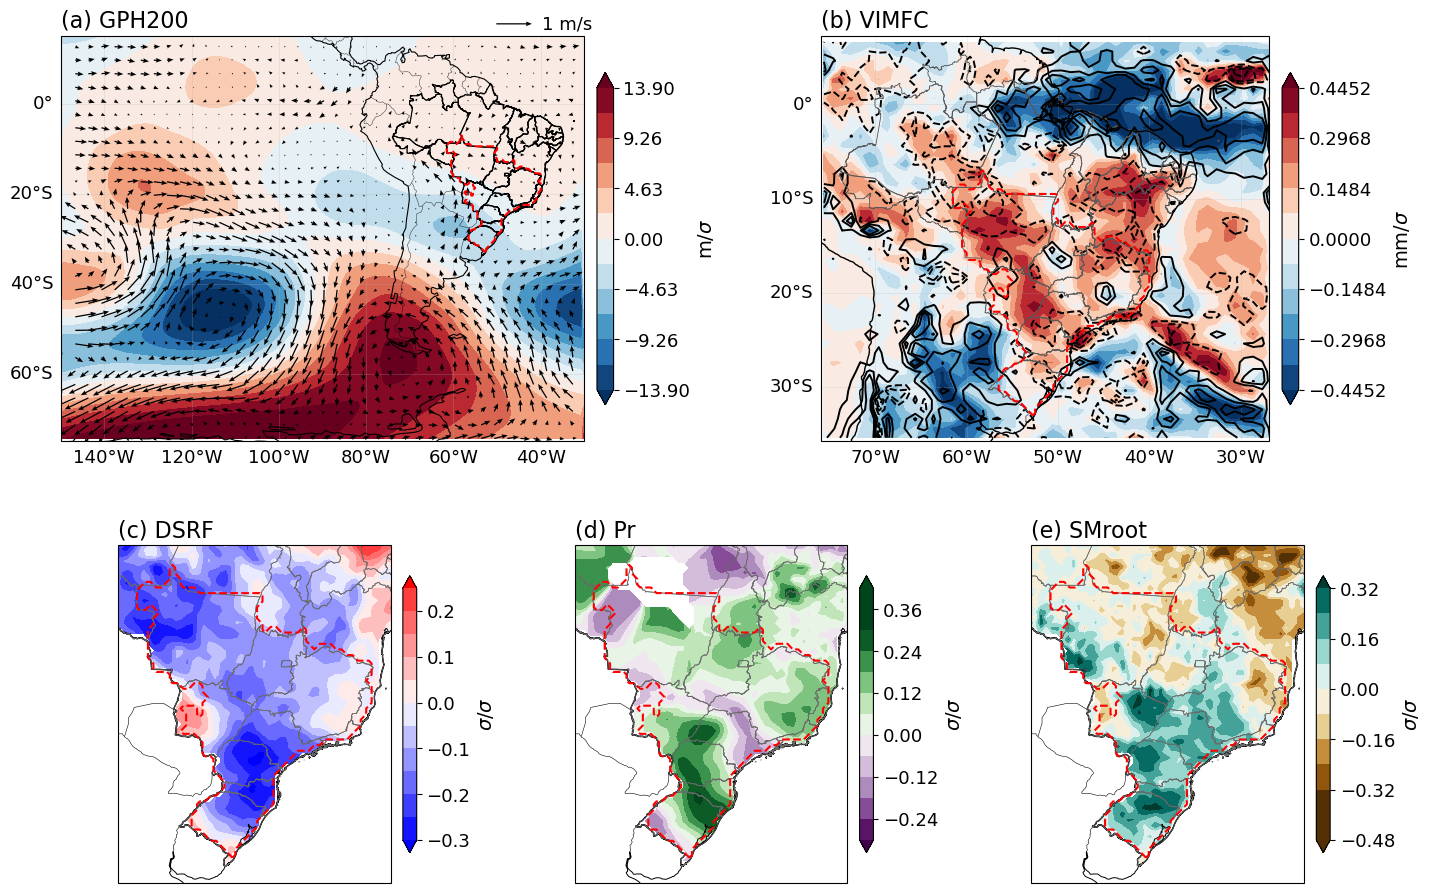

In [169]:
plot_jfm_ad_ond_5panel(
    hgt_reg=hgt200_JFM_SWPA_JFM,
    u_reg=uwnd850_JFM_SWPA_JFM,
    v_reg=vwnd850_JFM_SWPA_JFM,
    vimd_reg=vimd_JFM_SWPA_JFM,
    omega_reg=w_JFM_SWPA_JFM,

    lower1_reg=msdwswrf_JFM_SWPA_JFM,
    lower2_reg=pre_JFM_SWPA_JFM,
    lower3_reg=smroot_JFM_SWPA_JFM,
    lower_titles=['DSRF', 'Pr', 'SMroot'],

    Brazil=Brazil,
    BRA_shp=BRA_shp,
    state_gdf=Brazil,      # 州界线
    maize2d=maize2d,       # 红色虚线框范围
    country_gdf=BRA_shp,   # 国界
    savepath="/Volumes/limenghan/巴西玉米/论文图/Figure6_JFM_SWPA_JFM_5panel_case1.png",
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
)

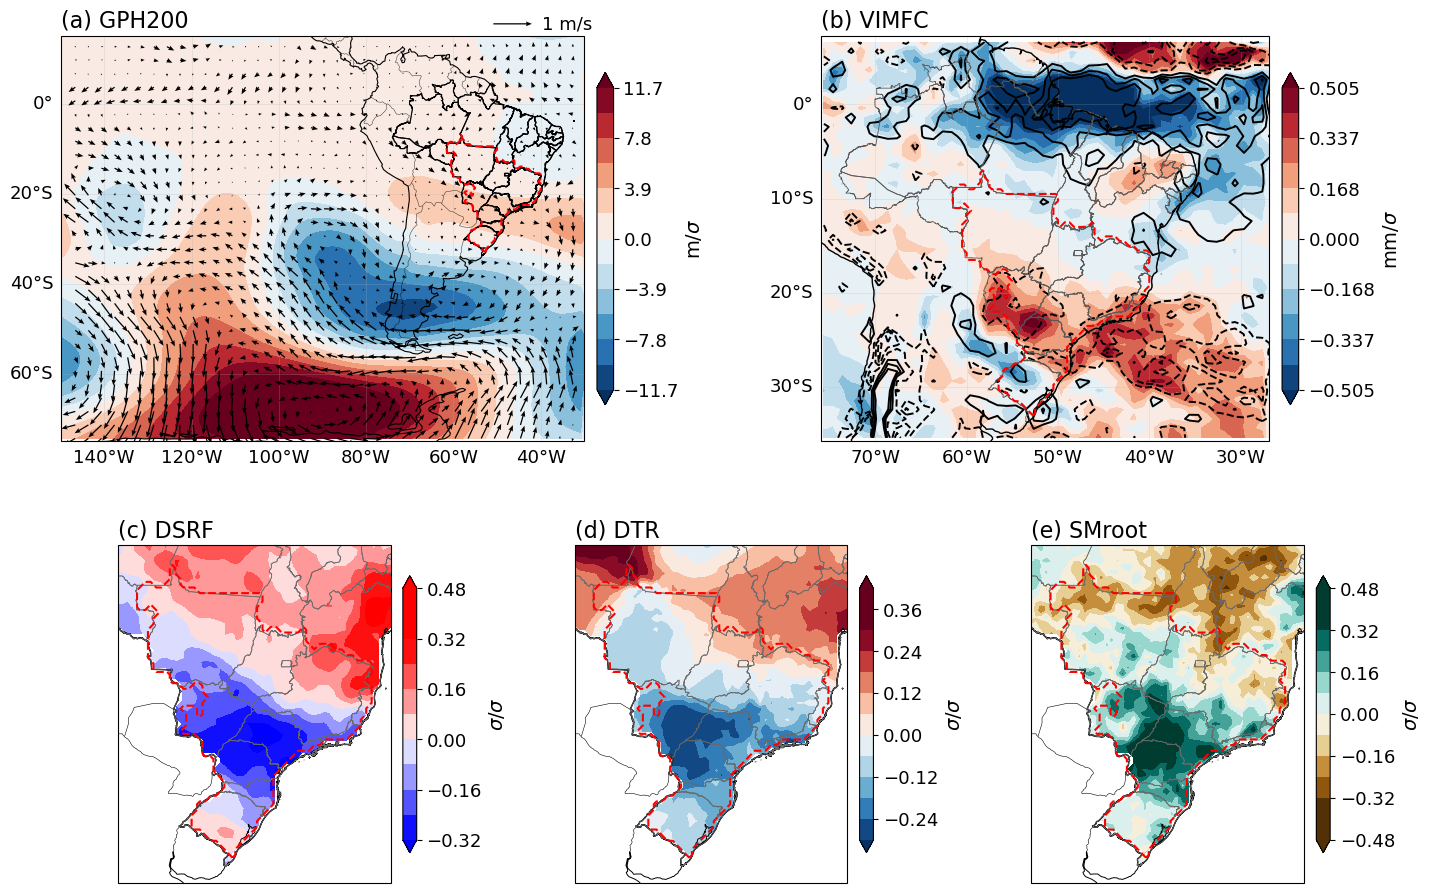

In [170]:
plot_jfm_ad_ond_5panel(
    hgt_reg=hgt200_AMJ_SWPA_AMJ,
    u_reg=uwnd850_AMJ_SWPA_AMJ,
    v_reg=vwnd850_AMJ_SWPA_AMJ,
    vimd_reg=vimd_AMJ_SWPA_AMJ,
    omega_reg=w_AMJ_SWPA_AMJ,

    lower1_reg=msdwswrf_AMJ_SWPA_AMJ,
    lower2_reg=dtr_AMJ_SWPA_AMJ,
    lower3_reg=smroot_AMJ_SWPA_AMJ,
    lower_titles=['DSRF', 'DTR', 'SMroot'],

    Brazil=Brazil,
    BRA_shp=BRA_shp,
    state_gdf=Brazil,
    maize2d=maize2d,
    country_gdf=BRA_shp,
    savepath="/Volumes/limenghan/巴西玉米/南极偶极子与环流/Figure7_AMJ_SWPA_AMJ_5panel_case2.png",
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
)

In [166]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# 你已有这些函数/对象：
# _ensure_lon180, _to_lon360, _as_da, _crop_box, _add_cyclic
# mask_by_geodf
# Brazil, BRA_shp


def _get_valid_box_from_dataarray(da):
    """
    根据 DataArray 中有效值区域获取外接框。
    若全场都有效，则返回 lon/lat 全范围。
    返回:
        lon_min, lon_max, lat_min, lat_max
    """
    if 'lon' not in da.coords or 'lat' not in da.coords:
        raise ValueError("maize2d 必须包含 lon 和 lat 坐标")

    lon = da['lon'].values
    lat = da['lat'].values
    val = da.values

    # 只看有限值区域
    mask = np.isfinite(val)

    # 若没有有效值，退化为全范围
    if mask.sum() == 0:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

    # 情况1：经纬度是一维
    if da['lon'].ndim == 1 and da['lat'].ndim == 1:
        if val.ndim != 2:
            # 如果不是二维，直接返回全范围
            return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

        lat_has = np.any(mask, axis=1)
        lon_has = np.any(mask, axis=0)

        lat_sel = lat[lat_has]
        lon_sel = lon[lon_has]

        return (
            float(np.nanmin(lon_sel)),
            float(np.nanmax(lon_sel)),
            float(np.nanmin(lat_sel)),
            float(np.nanmax(lat_sel))
        )

    # 情况2：经纬度是二维
    elif da['lon'].ndim == 2 and da['lat'].ndim == 2:
        lon2 = da['lon'].values
        lat2 = da['lat'].values
        return (
            float(np.nanmin(lon2[mask])),
            float(np.nanmax(lon2[mask])),
            float(np.nanmin(lat2[mask])),
            float(np.nanmax(lat2[mask]))
        )

    # 其他情况，回退到全范围
    else:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))


def _add_maize_box(ax, maize2d, color='red', lw=1.6, ls='--'):
    """
    在图上添加 maize2d 有效值区域的外接虚线框
    """
    if maize2d is None:
        return

    pc = ccrs.PlateCarree()
    lon0, lon1, lat0, lat1 = _get_valid_box_from_dataarray(maize2d)

    rect = mpatches.Rectangle(
        xy=(lon0, lat0),
        width=lon1 - lon0,
        height=lat1 - lat0,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        linestyle=ls,
        transform=pc,
        zorder=20
    )
    ax.add_patch(rect)


def _plot_hgt_panel(
    ax, hgt, u, v,
    Brazil=None,
    maize2d=None,
    extent=(-150, -30, -75, 15),
    pv_max=None,
    cmap="RdBu_r",
    hgt_levels=None,
    wind_step=3,
    wind_scale=None,
    quiver_key_speed=1.0,
    title=None,
    title_fontsize=15,
    label_fontsize=13,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    hgt = _ensure_lon180(hgt)
    u   = _ensure_lon180(u)
    v   = _ensure_lon180(v)

    hgt_da = -_as_da(hgt, "slope")
    u_da   = -_as_da(u, "slope")
    v_da   = -_as_da(v, "slope")

    pv_da = None
    if pv_max is not None:
        if isinstance(hgt, xr.Dataset) and ("pv" in hgt):
            pv_da = hgt["pv"]
        else:
            raise ValueError("pv_max 不为 None 时，需要 hgt 是包含 'pv' 的 xr.Dataset")

    lon0, lon1, lat0, lat1 = extent
    hgt_da = _crop_box(hgt_da, lon0, lon1, lat0, lat1)
    u_da   = _crop_box(u_da,   lon0, lon1, lat0, lat1)
    v_da   = _crop_box(v_da,   lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    u_da = u_da.interp_like(hgt_da, method="linear")
    v_da = v_da.interp_like(hgt_da, method="linear")

    G0 = 9.80665
    hgt_da = hgt_da / G0

    if pv_da is not None:
        pv_da = pv_da.interp_like(hgt_da, method="nearest")
        hgt_da = hgt_da.where(pv_da <= pv_max)

    if hgt_levels is None:
        a = float(np.nanpercentile(np.abs(hgt_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        hgt_levels = np.linspace(-a, a, 13)

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = hgt_da["lon"].values
    lat = hgt_da["lat"].values
    z_cyc, lon_cyc = _add_cyclic(hgt_da.values, lon)

    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=hgt_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    step = int(max(1, wind_step))
    uu = u_da.values[::step, ::step]
    vv = v_da.values[::step, ::step]
    LON, LAT = np.meshgrid(hgt_da["lon"].values, hgt_da["lat"].values)

    q = ax.quiver(
        LON[::step, ::step], LAT[::step, ::step],
        uu, vv,
        transform=pc,
        zorder=6,
        scale=wind_scale,
        scale_units="inches",
        angles="uv",
        width=0.0024,
        headwidth=3.8, headlength=4.8, headaxislength=4.2
    )
    ax.quiverkey(
        q, X=0.90, Y=1.03, U=quiver_key_speed,
        label=f"{quiver_key_speed:g} m/s",
        labelpos="E", coordinates="axes",
        fontproperties={"size": label_fontsize}
    )

    if Brazil is not None:
        try:
            Brazil.boundary.plot(
                ax=ax, transform=pc,
                edgecolor="black", linewidth=0.8, zorder=9
            )
        except TypeError:
            ax.add_geometries(
                Brazil.boundary.geometry, crs=pc,
                edgecolor="black", facecolor="none",
                linewidth=0.8, zorder=9
            )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=0.8, zorder=10)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.7, zorder=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r"m/$\sigma$", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _plot_vimd_panel(
    ax, vimd, omega, Brazil,
    maize2d=None,
    pad_deg=2.0,
    pv_max=None,
    cmap="RdBu_r",
    vimfc_levels=None,
    omega_nlevels=6,
    omega_lw=1.4,
    omega_label=False,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    if hasattr(Brazil, "crs") and (Brazil.crs is not None) and ("4326" not in str(Brazil.crs)):
        Brazil = Brazil.to_crs("EPSG:4326")

    vimd  = _to_lon360(vimd)
    omega = _to_lon360(omega)

    vimd_da  = -_as_da(vimd, "slope")
    omega_da = -_as_da(omega, "slope") if isinstance(omega, xr.Dataset) else omega

    pv_da = None
    if pv_max is not None:
        if isinstance(vimd, xr.Dataset) and ("pv" in vimd):
            pv_da = _to_lon360(vimd["pv"])
        else:
            raise ValueError("pv_max 不为 None 时，需要 vimd 是包含 'pv' 的 xr.Dataset")

    minx, miny, maxx, maxy = Brazil.total_bounds
    lon0 = (minx % 360) - pad_deg
    lon1 = (maxx % 360) + pad_deg
    if lon0 > lon1:
        lon0, lon1 = 0.0, 360.0
    lat0 = miny - pad_deg
    lat1 = maxy + pad_deg

    vimd_da  = _crop_box(vimd_da,  lon0, lon1, lat0, lat1)
    omega_da = _crop_box(omega_da, lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    omega_da = omega_da.interp_like(vimd_da, method="linear")
    vimfc_da = -vimd_da

    if pv_da is not None:
        pv_da = pv_da.interp_like(vimfc_da, method="nearest")
        vimfc_da = vimfc_da.where(pv_da <= pv_max)

    if vimfc_levels is None:
        a = float(np.nanpercentile(np.abs(vimfc_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        vimfc_levels = np.linspace(-a, a, 13)

    b = float(np.nanpercentile(np.abs(omega_da.values), 95))
    if not np.isfinite(b) or b == 0:
        b = 0.02
    n_half = max(1, int(omega_nlevels // 2))
    neg_levels = np.sort(-np.linspace(b, b/n_half, n_half))
    pos_levels = np.sort(np.linspace(b/n_half, b, n_half))

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = vimfc_da["lon"].values
    lat = vimfc_da["lat"].values

    z_cyc, lon_cyc = _add_cyclic(vimfc_da.values, lon)
    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=vimfc_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    om_cyc, lon_cyc2 = _add_cyclic(omega_da.values, lon)
    csn = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=neg_levels, colors="k",
        linewidths=omega_lw, linestyles="--",
        transform=pc, zorder=5
    )
    csp = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=pos_levels, colors="k",
        linewidths=omega_lw, linestyles="-",
        transform=pc, zorder=5
    )
    if omega_label:
        ax.clabel(csn, fontsize=tick_fontsize - 2, fmt="%.2g")
        ax.clabel(csp, fontsize=tick_fontsize - 2, fmt="%.2g")

    try:
        Brazil.boundary.plot(ax=ax, transform=pc, edgecolor="0.35", linewidth=0.6, zorder=8)
    except TypeError:
        ax.add_geometries(
            Brazil.boundary.geometry, crs=pc,
            edgecolor="0.35", facecolor="none", linewidth=0.6, zorder=8
        )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=1.0, zorder=9)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r'mm/$\sigma$', fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _mask_by_geodf_simple(da, country_gdf):
    return mask_by_geodf(da, country_gdf)

def _plot_scalar_panel(
    ax, data, country_gdf, variable_name,
    state_gdf=None,
    maize2d=None,
    cmap=None, vmin=None, vmax=None,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    draw_local_cbar=True,
    cbar_fontsize=13,
    use_maize_extent=True
):
    pc = ccrs.PlateCarree()

    da = -xr.DataArray(
        data['slope'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )
    pv = xr.DataArray(
        data['pv'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )

    # 仍然保留巴西区域mask
    da = _mask_by_geodf_simple(da, country_gdf)
    pv = _mask_by_geodf_simple(pv, country_gdf)

    lon = da["lon"].values
    lat = da["lat"].values

    if cmap is None or vmin is None or vmax is None:
        name = variable_name.lower()
        if name in ['dsrf', 'msdwswrf']:
            cmap, vmin, vmax = 'bwr', -0.3, 0.3
        elif name in ['pr', 'pre']:
            cmap, vmin, vmax = 'PRGn', -0.3, 0.3
        elif name in ['smroot']:
            cmap, vmin, vmax = 'BrBG', -0.36, 0.36
        elif name in ['dtr']:
            cmap, vmin, vmax = 'RdBu_r', -0.3, 0.3
        else:
            cmap, vmin, vmax = 'PuOr', -0.25, 0.25

    cf = ax.contourf(
        lon, lat, da.values,
        levels=13, cmap=cmap, vmin=vmin, vmax=vmax,
        transform=pc, extend='both'
    )

    # 显著性阴影/线
    mask = (pv.values < 0.1) & np.isfinite(pv.values)
    lons, lats = np.meshgrid(lon, lat)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                ax.fill_between(
                    [lons[i, j], lons[i, j] + 1],
                    lats[i, j], lats[i, j] + 1,
                    color='none', edgecolor='gray',
                    hatch='///', linewidth=0.08,
                    transform=pc
                )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # 国界
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    # 州界线
    if state_gdf is not None:
        state_gdf.boundary.plot(ax=ax, facecolor='none', edgecolor='dimgray', linewidth=0.5)

    # maize 外轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    # 关键修改：cde 的范围也按 maize2d 来
    if use_maize_extent and (maize2d is not None):
        extent = _get_maize_extent(maize2d, pad_lon=2.0, pad_lat=2.0)
        ax.set_extent(extent, crs=pc)
    else:
        minx, miny, maxx, maxy = country_gdf.total_bounds
        ax.set_extent([minx, maxx, miny - 5, maxy], crs=pc)

    # 刻度可以按 maize 范围自动一点，也可以先保留固定值
    ax.tick_params(labelsize=tick_fontsize)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    if draw_local_cbar:
        cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.03)
        cbar.set_label(r'$\sigma/\sigma$', fontsize=cbar_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def plot_jfm_ad_ond_5panel(
    hgt_reg, u_reg, v_reg,
    vimd_reg, omega_reg,
    lower1_reg, lower2_reg, lower3_reg,
    lower_titles,
    Brazil, BRA_shp=None,
    state_gdf=None,
    maize2d=None,
    country_gdf=None,
    savepath=None,
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
):
    """
    通用五面板函数：
    第一行：HGT200, VIMFC
    第二行：三个地表变量，可自由替换
    maize2d轮廓在 abcde 五个面板都画
    """

    if country_gdf is None:
        country_gdf = BRA_shp if BRA_shp is not None else Brazil

    fig = plt.figure(figsize=(17, 11))
    gs = fig.add_gridspec(
        2, 6,
        height_ratios=[1.2, 1.0],
        wspace=0.30,
        hspace=0.28
    )

    ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
    ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())

    ax3 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree())
    ax4 = fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree())
    ax5 = fig.add_subplot(gs[1, 4:6], projection=ccrs.PlateCarree())

    _plot_hgt_panel(
        ax1, hgt_reg, u_reg, v_reg,
        Brazil=Brazil,
        maize2d=maize2d,
        extent=(-150, -30, -75, 15),
        title="(a) GPH200*(-1)",
        title_fontsize=fontsize_title,
        label_fontsize=fontsize_tick,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_vimd_panel(
        ax2, vimd_reg, omega_reg, Brazil=Brazil,
        maize2d=maize2d,
        title="(b) VIMFC*(-1)",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax3, lower1_reg, country_gdf, lower_titles[0],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(c) {lower_titles[0]}*(-1)",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax4, lower2_reg, country_gdf, lower_titles[1],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(d) {lower_titles[1]}*(-1)",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax5, lower3_reg, country_gdf, lower_titles[2],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(e) {lower_titles[2]}*(-1)",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

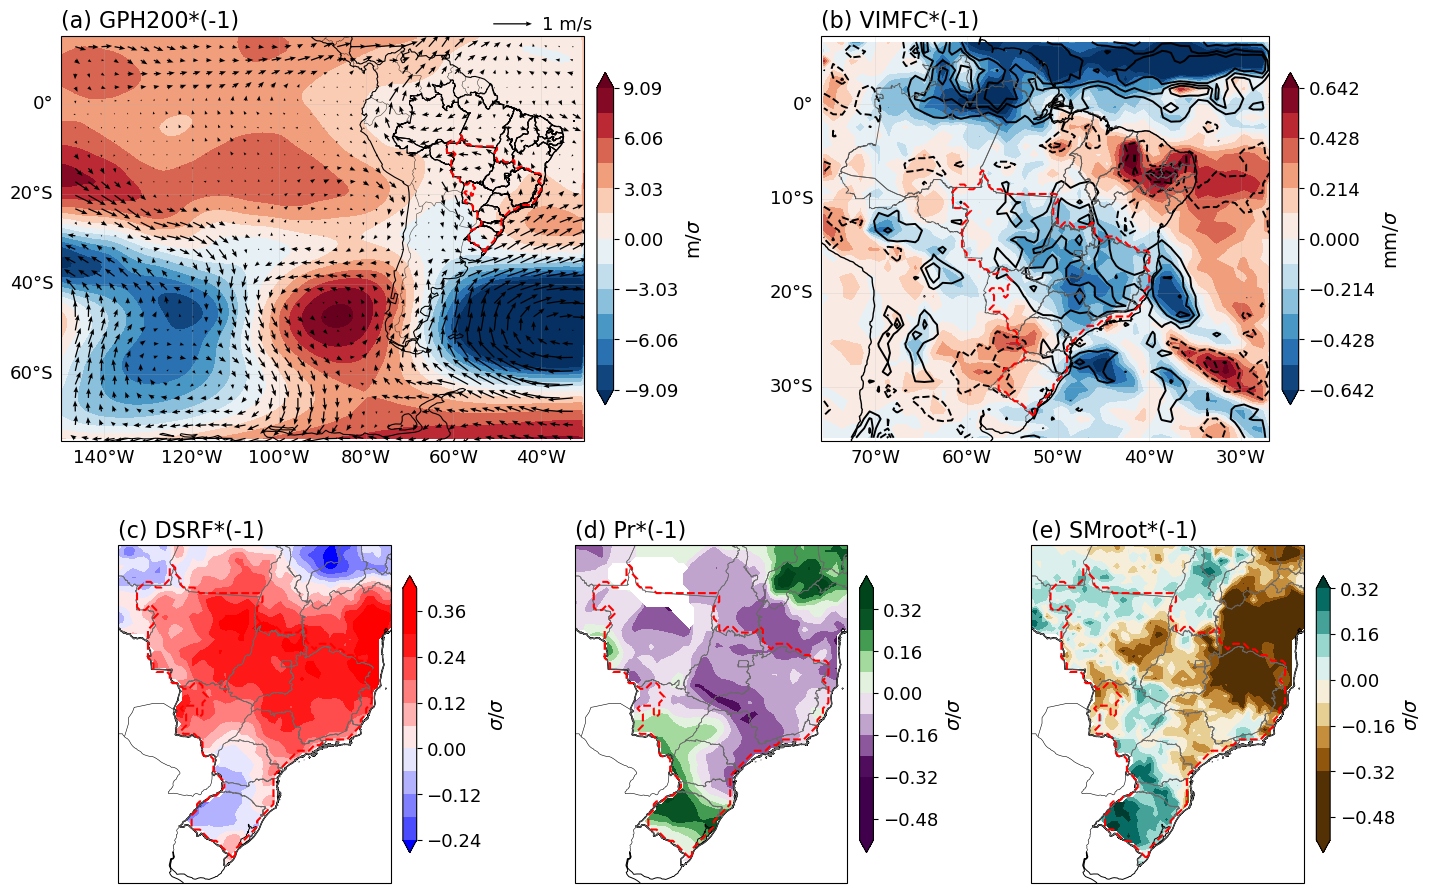

In [167]:
plot_jfm_ad_ond_5panel(
    hgt_reg=hgt200_JFM_SWA_JFM,
    u_reg=uwnd850_JFM_SWA_JFM,
    v_reg=vwnd850_JFM_SWA_JFM,
    vimd_reg=vimd_JFM_SWA_JFM,
    omega_reg=w_JFM_SWA_JFM,

    lower1_reg=msdwswrf_JFM_SWA_JFM,
    lower2_reg=pre_JFM_SWA_JFM,
    lower3_reg=smroot_JFM_SWA_JFM,
    lower_titles=['DSRF', 'Pr', 'SMroot'],

    Brazil=Brazil,
    BRA_shp=BRA_shp,
    state_gdf=Brazil,      # 州界线
    maize2d=maize2d,       # 红色虚线框范围
    country_gdf=BRA_shp,   # 国界
    savepath="/Volumes/limenghan/巴西玉米/论文图/Figure6_JFM_SWA_JFM_5panel_case1.png",
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
)

In [171]:
for i in ['sic']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_AD_NDJ']=reg_location_global(AD_NDJ_1_mean_std,locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_AD_NDJ')

已计算sic_JFM_AD_NDJ
已计算sic_AMJ_AD_NDJ


In [172]:
sic_JFM_AD_NDJ

<xarray.Dataset>
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    slope    (lat, lon) float64 0.0 0.0 0.0 ... -0.0002701 -0.0002687 -0.0002696
    pv       (lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.2255 0.2212 0.2274 0.2232
Attributes:
    description:  Regression Results

In [174]:
for i in ['slp']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_AD_NDJ']=reg_location_global(AD_NDJ_1_mean_std,locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_AD_NDJ')


KeyboardInterrupt



In [190]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.patches as mpatches


def add_cyclic_2d(lon, data2d):
    """
    给二维经向周期数据补一个循环点，避免经度拼接空缝
    lon: 1D longitude
    data2d: 2D array (lat, lon)
    """
    lon_new = np.concatenate([lon, [lon[0] + 360]])
    data_new = np.concatenate([data2d, data2d[:, 0:1]], axis=1)
    return lon_new, data_new


def plot_antarctic_sic_two_panel(
    sic_jfm,
    sic_amj,
    savepath=None,
    cbar_label='SIC / $\sigma$',
    cmap='RdBu_r',
    fontsize_title=17,
    fontsize_tick=13,
    fontsize_cbar=14
):
    """
    sic_jfm, sic_amj: xarray.Dataset
        需要包含变量:
        - slope(lat, lon)
    """

    lon = sic_jfm['lon'].values
    lat = sic_jfm['lat'].values

    sic_jfm_slope = sic_jfm['slope'].values
    sic_amj_slope = sic_amj['slope'].values

    # 加 cyclic point
    lon_cyc, sic_jfm_cyc = add_cyclic_2d(lon, sic_jfm_slope)
    _, sic_amj_cyc = add_cyclic_2d(lon, sic_amj_slope)
    Lon_cyc, Lat_cyc = np.meshgrid(lon_cyc, lat)

    # 共用色标范围
    vabs1 = np.nanquantile(np.abs(sic_jfm_cyc), 0.98)
    vabs2 = np.nanquantile(np.abs(sic_amj_cyc), 0.98)
    vabs = np.nanmax([vabs1, vabs2])

    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = np.nanmax(np.abs(np.concatenate([sic_jfm_cyc.ravel(), sic_amj_cyc.ravel()])))
    if (not np.isfinite(vabs)) or (vabs == 0):
        vabs = 1e-6

    levels = np.linspace(-vabs, vabs, 21)

    proj = ccrs.SouthPolarStereo()
    data_crs = ccrs.PlateCarree()

    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 6.8),  # 调整图的大小
        subplot_kw={'projection': proj}
    )

    # 关键：增大 bottom，避免和 colorbar 重叠
    plt.subplots_adjust(left=0.05, right=0.96, bottom=0.18, top=0.90, wspace=0.14)

    panels = [
        (axes[0], sic_jfm_cyc, '(a) JFM SIC'),
        (axes[1], sic_amj_cyc, '(b) AMJ SIC')
    ]

    cf_last = None

    for ax, sic_field, title in panels:
        # 南极范围：修改纬度显示到 50°S
        ax.set_extent([-180, 180, -90, -50], crs=data_crs)

        # 圆形边界
        theta = np.linspace(0, 2 * np.pi, 200)
        center, radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform=ax.transAxes)

        # 海洋背景直接白色
        ax.set_facecolor('white')

        # 填色
        cf = ax.contourf(
            Lon_cyc, Lat_cyc, sic_field,
            levels=levels,
            cmap=cmap,
            extend='both',
            transform=data_crs,
            zorder=1
        )
        cf_last = cf

        # 陆地和海岸线
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
        ax.coastlines(linewidth=0.8, zorder=4)

        # 经纬网
        gl = ax.gridlines(
            crs=data_crs,
            draw_labels=True,
            linewidth=0.6,
            color='gray',
            alpha=0.7,
            linestyle='--'
        )
        gl.xlocator = FixedLocator(np.arange(-180, 181, 60))
        gl.ylocator = FixedLocator([-80, -70, -60, -50])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': fontsize_tick}
        gl.ylabel_style = {'size': fontsize_tick}

        # 标题放在左上方
        ax.text(
            -0.05, 0.95, title,
            transform=ax.transAxes,
            fontsize=fontsize_title,
            ha='left', va='top'
        )

        # 红框：10°W–60°W, 70°S–60°S 区域
        rect = mpatches.Rectangle(
            xy=(-60, -70),
            width=50,
            height=10,
            fill=False,
            edgecolor='red',
            linewidth=1.8,
            transform=data_crs,
            zorder=5
        )
        ax.add_patch(rect)

    # 关键：手动加一个更靠下的 colorbar 轴
    cax = fig.add_axes([0.20, 0.08, 0.60, 0.035])  # [left, bottom, width, height]
    cbar = fig.colorbar(
        cf_last,
        cax=cax,
        orientation='horizontal'
    )
    cbar.set_label(cbar_label, fontsize=fontsize_cbar)
    cbar.ax.tick_params(labelsize=fontsize_tick)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

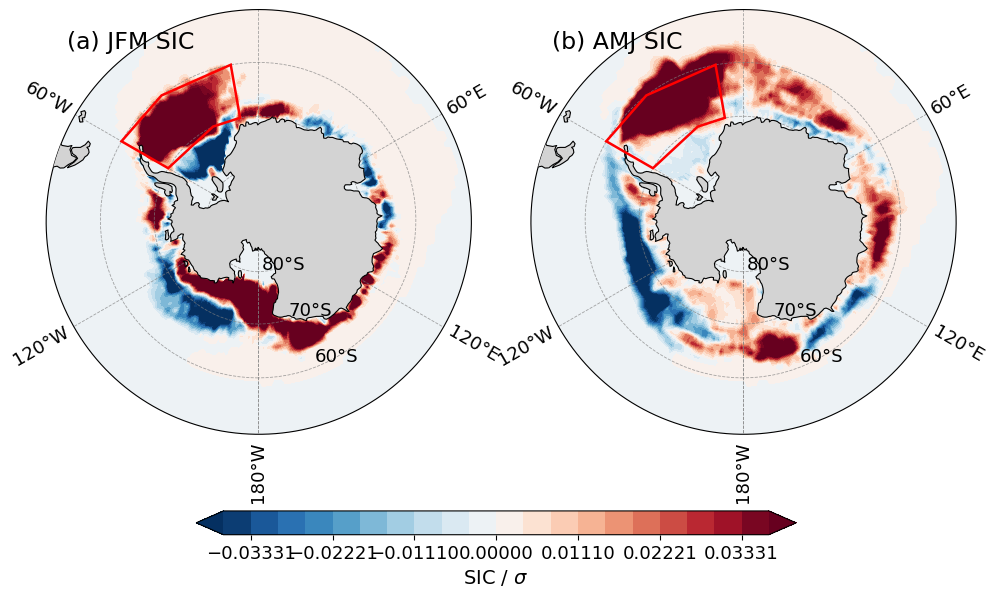

In [191]:
plot_antarctic_sic_two_panel(
    sic_jfm=sic_JFM_AD_NDJ,
    sic_amj=sic_AMJ_AD_NDJ,
    savepath='/Volumes/limenghan/巴西玉米/论文图/Figure8_antarctic_SIC_two_panel.png',
    cbar_label='SIC / $\sigma$'
)

In [192]:
# 1. 选取区域：10°W–60°W, 70°S–60°S
sic_region_JFM = sic_JFM_nosig.sel(
    lon=slice(-60, -10),
    lat=slice(-70, -60)
)
sic_region_AMJ = sic_AMJ_nosig.sel(
    lon=slice(-60, -10),
    lat=slice(-70, -60)
)

# 2. 计算纬度加权区域平均
weights_JFM = np.cos(np.deg2rad(sic_region_JFM['lat']))
weights_AMJ = np.cos(np.deg2rad(sic_region_AMJ['lat']))
SASIC_JFM = sic_region_JFM.weighted(weights_JFM).mean(dim=['lat', 'lon'])
SASIC_AMJ = sic_region_AMJ.weighted(weights_AMJ).mean(dim=['lat', 'lon'])

# 3. 标准化
SASIC_std_JFM = (SASIC_JFM - SASIC_JFM.mean(dim='season_year')) / SASIC_JFM.std(dim='season_year')
SASIC_std_AMJ = (SASIC_AMJ - SASIC_AMJ.mean(dim='season_year')) / SASIC_AMJ.std(dim='season_year')

# 4. 改名
SASIC_JFM = SASIC_std_JFM.rename('SASIC_std_JFM')
SASIC_AMJ = SASIC_std_AMJ.rename('SASIC_std_AMJ')


In [195]:
SASIC_AMJ=SASIC_AMJ.to_series()
SASIC_JFM=SASIC_JFM.to_series()

In [197]:
for i in ['dtr', 'cld', 'pre', 'msdwswrf', 'smroot']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SASIC_{time}']=reg_location_bootstrap_like_reg_location(locals()[f'SASIC_{time}'],locals()[f'{i}_{time}_nosig'],
            n_boot=1000,
            seed=0,
            return_ci=True,)
        print(f'已计算{i}_{time}_SASIC_{time}')
#for i in ['hgt200','hgt500','hgt850','slp']:
for i in ['hgt200','vwnd850','uwnd850']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SASIC_{time}']=reg_location_global(locals()[f'SASIC_{time}'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SASIC_{time}')

已计算dtr_JFM_SASIC_JFM
已计算dtr_AMJ_SASIC_AMJ
已计算cld_JFM_SASIC_JFM
已计算cld_AMJ_SASIC_AMJ
已计算pre_JFM_SASIC_JFM
已计算pre_AMJ_SASIC_AMJ
已计算msdwswrf_JFM_SASIC_JFM
已计算msdwswrf_AMJ_SASIC_AMJ
已计算smroot_JFM_SASIC_JFM
已计算smroot_AMJ_SASIC_AMJ
已计算hgt200_JFM_SASIC_JFM
已计算hgt200_AMJ_SASIC_AMJ
已计算vwnd850_JFM_SASIC_JFM
已计算vwnd850_AMJ_SASIC_AMJ
已计算uwnd850_JFM_SASIC_JFM
已计算uwnd850_AMJ_SASIC_AMJ


In [201]:
for i in ['vimd','w']:
    for time in ['JFM','AMJ']:
        locals()[f'{i}_{time}_SASIC_{time}']=reg_location_global(locals()[f'SASIC_{time}'],locals()[f'{i}_{time}_nosig'])
        print(f'已计算{i}_{time}_SASIC_{time}')

已计算vimd_JFM_SASIC_JFM
已计算vimd_AMJ_SASIC_AMJ
已计算w_JFM_SASIC_JFM
已计算w_AMJ_SASIC_AMJ


In [223]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# 你已有这些函数/对象：
# _ensure_lon180, _to_lon360, _as_da, _crop_box, _add_cyclic
# mask_by_geodf
# Brazil, BRA_shp


def _get_valid_box_from_dataarray(da):
    """
    根据 DataArray 中有效值区域获取外接框。
    若全场都有效，则返回 lon/lat 全范围。
    返回:
        lon_min, lon_max, lat_min, lat_max
    """
    if 'lon' not in da.coords or 'lat' not in da.coords:
        raise ValueError("maize2d 必须包含 lon 和 lat 坐标")

    lon = da['lon'].values
    lat = da['lat'].values
    val = da.values

    # 只看有限值区域
    mask = np.isfinite(val)

    # 若没有有效值，退化为全范围
    if mask.sum() == 0:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

    # 情况1：经纬度是一维
    if da['lon'].ndim == 1 and da['lat'].ndim == 1:
        if val.ndim != 2:
            # 如果不是二维，直接返回全范围
            return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))

        lat_has = np.any(mask, axis=1)
        lon_has = np.any(mask, axis=0)

        lat_sel = lat[lat_has]
        lon_sel = lon[lon_has]

        return (
            float(np.nanmin(lon_sel)),
            float(np.nanmax(lon_sel)),
            float(np.nanmin(lat_sel)),
            float(np.nanmax(lat_sel))
        )

    # 情况2：经纬度是二维
    elif da['lon'].ndim == 2 and da['lat'].ndim == 2:
        lon2 = da['lon'].values
        lat2 = da['lat'].values
        return (
            float(np.nanmin(lon2[mask])),
            float(np.nanmax(lon2[mask])),
            float(np.nanmin(lat2[mask])),
            float(np.nanmax(lat2[mask]))
        )

    # 其他情况，回退到全范围
    else:
        return float(np.nanmin(lon)), float(np.nanmax(lon)), float(np.nanmin(lat)), float(np.nanmax(lat))


def _add_maize_box(ax, maize2d, color='red', lw=1.6, ls='--'):
    """
    在图上添加 maize2d 有效值区域的外接虚线框
    """
    if maize2d is None:
        return

    pc = ccrs.PlateCarree()
    lon0, lon1, lat0, lat1 = _get_valid_box_from_dataarray(maize2d)

    rect = mpatches.Rectangle(
        xy=(lon0, lat0),
        width=lon1 - lon0,
        height=lat1 - lat0,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        linestyle=ls,
        transform=pc,
        zorder=20
    )
    ax.add_patch(rect)


def _plot_hgt_panel(
    ax, hgt, u, v,
    Brazil=None,
    maize2d=None,
    extent=(-80, -30, -75, 15),
    pv_max=None,
    cmap="RdBu_r",
    hgt_levels=None,
    wind_step=3,
    wind_scale=None,
    quiver_key_speed=1.0,
    title=None,
    title_fontsize=15,
    label_fontsize=13,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    hgt = _ensure_lon180(hgt)
    u   = _ensure_lon180(u)
    v   = _ensure_lon180(v)

    hgt_da = _as_da(hgt, "slope")
    u_da   = _as_da(u, "slope")
    v_da   = _as_da(v, "slope")

    pv_da = None
    if pv_max is not None:
        if isinstance(hgt, xr.Dataset) and ("pv" in hgt):
            pv_da = hgt["pv"]
        else:
            raise ValueError("pv_max 不为 None 时，需要 hgt 是包含 'pv' 的 xr.Dataset")

    lon0, lon1, lat0, lat1 = extent
    hgt_da = _crop_box(hgt_da, lon0, lon1, lat0, lat1)
    u_da   = _crop_box(u_da,   lon0, lon1, lat0, lat1)
    v_da   = _crop_box(v_da,   lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    u_da = u_da.interp_like(hgt_da, method="linear")
    v_da = v_da.interp_like(hgt_da, method="linear")

    G0 = 9.80665
    hgt_da = hgt_da / G0

    if pv_da is not None:
        pv_da = pv_da.interp_like(hgt_da, method="nearest")
        hgt_da = hgt_da.where(pv_da <= pv_max)

    if hgt_levels is None:
        a = float(np.nanpercentile(np.abs(hgt_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        hgt_levels = np.linspace(-a, a, 13)

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = hgt_da["lon"].values
    lat = hgt_da["lat"].values
    z_cyc, lon_cyc = _add_cyclic(hgt_da.values, lon)

    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=hgt_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    step = int(max(1, wind_step))
    uu = u_da.values[::step, ::step]
    vv = v_da.values[::step, ::step]
    LON, LAT = np.meshgrid(hgt_da["lon"].values, hgt_da["lat"].values)

    q = ax.quiver(
        LON[::step, ::step], LAT[::step, ::step],
        uu, vv,
        transform=pc,
        zorder=6,
        scale=wind_scale,
        scale_units="inches",
        angles="uv",
        width=0.0024,
        headwidth=3.8, headlength=4.8, headaxislength=4.2
    )
    ax.quiverkey(
        q, X=0.90, Y=1.03, U=quiver_key_speed,
        label=f"{quiver_key_speed:g} m/s",
        labelpos="E", coordinates="axes",
        fontproperties={"size": label_fontsize}
    )

    if Brazil is not None:
        try:
            Brazil.boundary.plot(
                ax=ax, transform=pc,
                edgecolor="black", linewidth=0.8, zorder=9
            )
        except TypeError:
            ax.add_geometries(
                Brazil.boundary.geometry, crs=pc,
                edgecolor="black", facecolor="none",
                linewidth=0.8, zorder=9
            )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=0.8, zorder=10)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.7, zorder=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r"m/$\sigma$", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _plot_vimd_panel(
    ax, vimd, omega, Brazil,
    maize2d=None,
    pad_deg=2.0,
    pv_max=None,
    cmap="RdBu_r",
    vimfc_levels=None,
    omega_nlevels=6,
    omega_lw=1.4,
    omega_label=False,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    cbar_fontsize=13
):
    pc = ccrs.PlateCarree()

    if hasattr(Brazil, "crs") and (Brazil.crs is not None) and ("4326" not in str(Brazil.crs)):
        Brazil = Brazil.to_crs("EPSG:4326")

    vimd  = _to_lon360(vimd)
    omega = _to_lon360(omega)

    vimd_da  = _as_da(vimd, "slope")
    omega_da = _as_da(omega, "slope") if isinstance(omega, xr.Dataset) else omega

    pv_da = None
    if pv_max is not None:
        if isinstance(vimd, xr.Dataset) and ("pv" in vimd):
            pv_da = _to_lon360(vimd["pv"])
        else:
            raise ValueError("pv_max 不为 None 时，需要 vimd 是包含 'pv' 的 xr.Dataset")

    minx, miny, maxx, maxy = Brazil.total_bounds
    lon0 = (minx % 360) - pad_deg
    lon1 = (maxx % 360) + pad_deg
    if lon0 > lon1:
        lon0, lon1 = 0.0, 360.0
    lat0 = miny - pad_deg
    lat1 = maxy + pad_deg

    vimd_da  = _crop_box(vimd_da,  lon0, lon1, lat0, lat1)
    omega_da = _crop_box(omega_da, lon0, lon1, lat0, lat1)
    if pv_da is not None:
        pv_da = _crop_box(pv_da, lon0, lon1, lat0, lat1)

    omega_da = omega_da.interp_like(vimd_da, method="linear")
    vimfc_da = -vimd_da

    if pv_da is not None:
        pv_da = pv_da.interp_like(vimfc_da, method="nearest")
        vimfc_da = vimfc_da.where(pv_da <= pv_max)

    if vimfc_levels is None:
        a = float(np.nanpercentile(np.abs(vimfc_da.values), 95))
        if not np.isfinite(a) or a == 0:
            a = 1.0
        vimfc_levels = np.linspace(-a, a, 13)

    b = float(np.nanpercentile(np.abs(omega_da.values), 95))
    if not np.isfinite(b) or b == 0:
        b = 0.02
    n_half = max(1, int(omega_nlevels // 2))
    neg_levels = np.sort(-np.linspace(b, b/n_half, n_half))
    pos_levels = np.sort(np.linspace(b/n_half, b, n_half))

    ax.set_extent([lon0, lon1, lat0, lat1], crs=pc)
    ax.set_facecolor("white")

    lon = vimfc_da["lon"].values
    lat = vimfc_da["lat"].values

    z_cyc, lon_cyc = _add_cyclic(vimfc_da.values, lon)
    cf = ax.contourf(
        lon_cyc, lat, z_cyc,
        levels=vimfc_levels, cmap=cmap, extend="both",
        transform=pc, zorder=1
    )

    om_cyc, lon_cyc2 = _add_cyclic(omega_da.values, lon)
    csn = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=neg_levels, colors="k",
        linewidths=omega_lw, linestyles="--",
        transform=pc, zorder=5
    )
    csp = ax.contour(
        lon_cyc2, lat, om_cyc,
        levels=pos_levels, colors="k",
        linewidths=omega_lw, linestyles="-",
        transform=pc, zorder=5
    )
    if omega_label:
        ax.clabel(csn, fontsize=tick_fontsize - 2, fmt="%.2g")
        ax.clabel(csp, fontsize=tick_fontsize - 2, fmt="%.2g")

    try:
        Brazil.boundary.plot(ax=ax, transform=pc, edgecolor="0.35", linewidth=0.6, zorder=8)
    except TypeError:
        ax.add_geometries(
            Brazil.boundary.geometry, crs=pc,
            edgecolor="0.35", facecolor="none", linewidth=0.6, zorder=8
        )

    # maize轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    ax.coastlines(linewidth=1.0, zorder=9)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.right_labels = False
    gl.top_labels = False
    gl.xlabel_style = {'size': tick_fontsize}
    gl.ylabel_style = {'size': tick_fontsize}

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.02, orientation="vertical")
    cbar.set_label(r'mm/$\sigma$', fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def _mask_by_geodf_simple(da, country_gdf):
    return mask_by_geodf(da, country_gdf)

def _plot_scalar_panel(
    ax, data, country_gdf, variable_name,
    state_gdf=None,
    maize2d=None,
    cmap=None, vmin=None, vmax=None,
    title=None,
    title_fontsize=15,
    tick_fontsize=12,
    draw_local_cbar=True,
    cbar_fontsize=13,
    use_maize_extent=True
):
    pc = ccrs.PlateCarree()

    da = xr.DataArray(
        data['slope'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )
    pv = xr.DataArray(
        data['pv'],
        coords={'lat': data['lat'], 'lon': data['lon']},
        dims=('lat', 'lon')
    )

    # 仍然保留巴西区域mask
    da = _mask_by_geodf_simple(da, country_gdf)
    pv = _mask_by_geodf_simple(pv, country_gdf)

    lon = da["lon"].values
    lat = da["lat"].values

    if cmap is None or vmin is None or vmax is None:
        name = variable_name.lower()
        if name in ['dsrf', 'msdwswrf']:
            cmap, vmin, vmax = 'bwr', -0.3, 0.3
        elif name in ['pr', 'pre']:
            cmap, vmin, vmax = 'PRGn', -0.3, 0.3
        elif name in ['smroot']:
            cmap, vmin, vmax = 'BrBG', -0.36, 0.36
        elif name in ['dtr']:
            cmap, vmin, vmax = 'RdBu_r', -0.3, 0.3
        else:
            cmap, vmin, vmax = 'PuOr', -0.25, 0.25

    cf = ax.contourf(
        lon, lat, da.values,
        levels=13, cmap=cmap, vmin=vmin, vmax=vmax,
        transform=pc, extend='both'
    )

    # 显著性阴影/线
    mask = (pv.values < 0.1) & np.isfinite(pv.values)
    lons, lats = np.meshgrid(lon, lat)
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                ax.fill_between(
                    [lons[i, j], lons[i, j] + 1],
                    lats[i, j], lats[i, j] + 1,
                    color='none', edgecolor='gray',
                    hatch='///', linewidth=0.08,
                    transform=pc
                )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # 国界
    country_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    # 州界线
    if state_gdf is not None:
        state_gdf.boundary.plot(ax=ax, facecolor='none', edgecolor='dimgray', linewidth=0.5)

    # maize 外轮廓
    _add_maize_outline(ax, maize2d, color='red', lw=1.5, ls='--')

    # 关键修改：cde 的范围也按 maize2d 来
    if use_maize_extent and (maize2d is not None):
        extent = _get_maize_extent(maize2d, pad_lon=2.0, pad_lat=2.0)
        ax.set_extent(extent, crs=pc)
    else:
        minx, miny, maxx, maxy = country_gdf.total_bounds
        ax.set_extent([minx, maxx, miny - 5, maxy], crs=pc)

    # 刻度可以按 maize 范围自动一点，也可以先保留固定值
    ax.tick_params(labelsize=tick_fontsize)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, loc='left', fontweight='normal')

    if draw_local_cbar:
        cbar = plt.colorbar(cf, ax=ax, shrink=0.82, pad=0.03)
        cbar.set_label(r'$\sigma/\sigma$', fontsize=cbar_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    return cf
def plot_jfm_ad_ond_5panel(
    hgt_reg, u_reg, v_reg,
    vimd_reg, omega_reg,
    lower1_reg, lower2_reg, lower3_reg,
    lower_titles,
    Brazil, BRA_shp=None,
    state_gdf=None,
    maize2d=None,
    country_gdf=None,
    savepath=None,
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
):
    """
    通用五面板函数：
    第一行：HGT200, VIMFC
    第二行：三个地表变量，可自由替换
    maize2d轮廓在 abcde 五个面板都画
    """

    if country_gdf is None:
        country_gdf = BRA_shp if BRA_shp is not None else Brazil

    fig = plt.figure(figsize=(17, 11))
    gs = fig.add_gridspec(
        2, 6,
        height_ratios=[1.2, 1.0],
        wspace=0.30,
        hspace=0.28
    )

    ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
    ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())

    ax3 = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree())
    ax4 = fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree())
    ax5 = fig.add_subplot(gs[1, 4:6], projection=ccrs.PlateCarree())

    _plot_hgt_panel(
        ax1, hgt_reg, u_reg, v_reg,
        Brazil=Brazil,
        maize2d=maize2d,
        extent=(-90, 10, -75, 15),
        title="(a) GPH200",
        title_fontsize=fontsize_title,
        label_fontsize=fontsize_tick,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_vimd_panel(
        ax2, vimd_reg, omega_reg, Brazil=Brazil,
        maize2d=maize2d,
        title="(b) VIMFC",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax3, lower1_reg, country_gdf, lower_titles[0],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(c) {lower_titles[0]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax4, lower2_reg, country_gdf, lower_titles[1],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(d) {lower_titles[1]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    _plot_scalar_panel(
        ax5, lower3_reg, country_gdf, lower_titles[2],
        state_gdf=state_gdf,
        maize2d=maize2d,
        title=f"(e) {lower_titles[2]}",
        title_fontsize=fontsize_title,
        tick_fontsize=fontsize_tick,
        draw_local_cbar=True,
        cbar_fontsize=fontsize_cbar
    )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()

In [224]:
hgt200_JFM_SASIC_JFM

<xarray.Dataset>
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float32 -89.38 -88.38 -87.38 -86.38 ... 87.62 88.62 89.62
  * lon      (lon) float32 -179.6 -178.6 -177.6 -176.6 ... 177.4 178.4 179.4
Data variables:
    slope    (lat, lon) float64 8.912 9.161 9.25 9.212 ... 91.51 91.42 91.45
    pv       (lat, lon) float64 0.8795 0.8761 0.8749 ... 0.4971 0.4975 0.4974
Attributes:
    description:  Regression Results

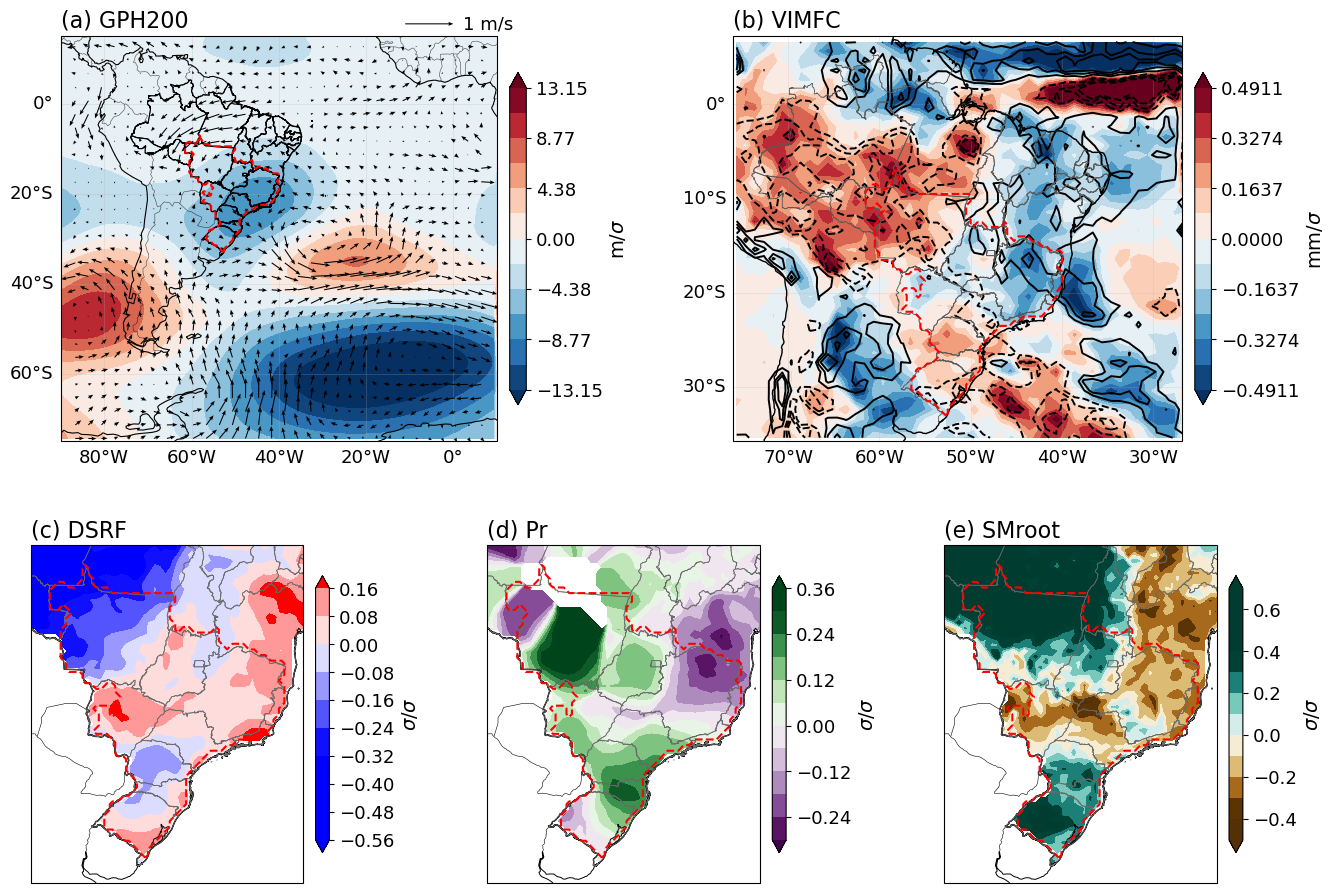

In [225]:
plot_jfm_ad_ond_5panel(
    hgt_reg=hgt200_JFM_SASIC_JFM,
    u_reg=uwnd850_JFM_SASIC_JFM,
    v_reg=vwnd850_JFM_SASIC_JFM,
    vimd_reg=vimd_JFM_SASIC_JFM,
    omega_reg=w_JFM_SASIC_JFM,

    lower1_reg=msdwswrf_JFM_SASIC_JFM,
    lower2_reg=pre_JFM_SASIC_JFM,
    lower3_reg=smroot_JFM_SASIC_JFM,
    lower_titles=['DSRF', 'Pr', 'SMroot'],

    Brazil=Brazil,
    BRA_shp=BRA_shp,
    state_gdf=Brazil,      # 州界线
    maize2d=maize2d,       # 红色虚线框范围
    country_gdf=BRA_shp,   # 国界
    savepath="/Volumes/limenghan/巴西玉米/论文图/Figure9_JFM_SASIC_JFM_5panel_case1.png",
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
)

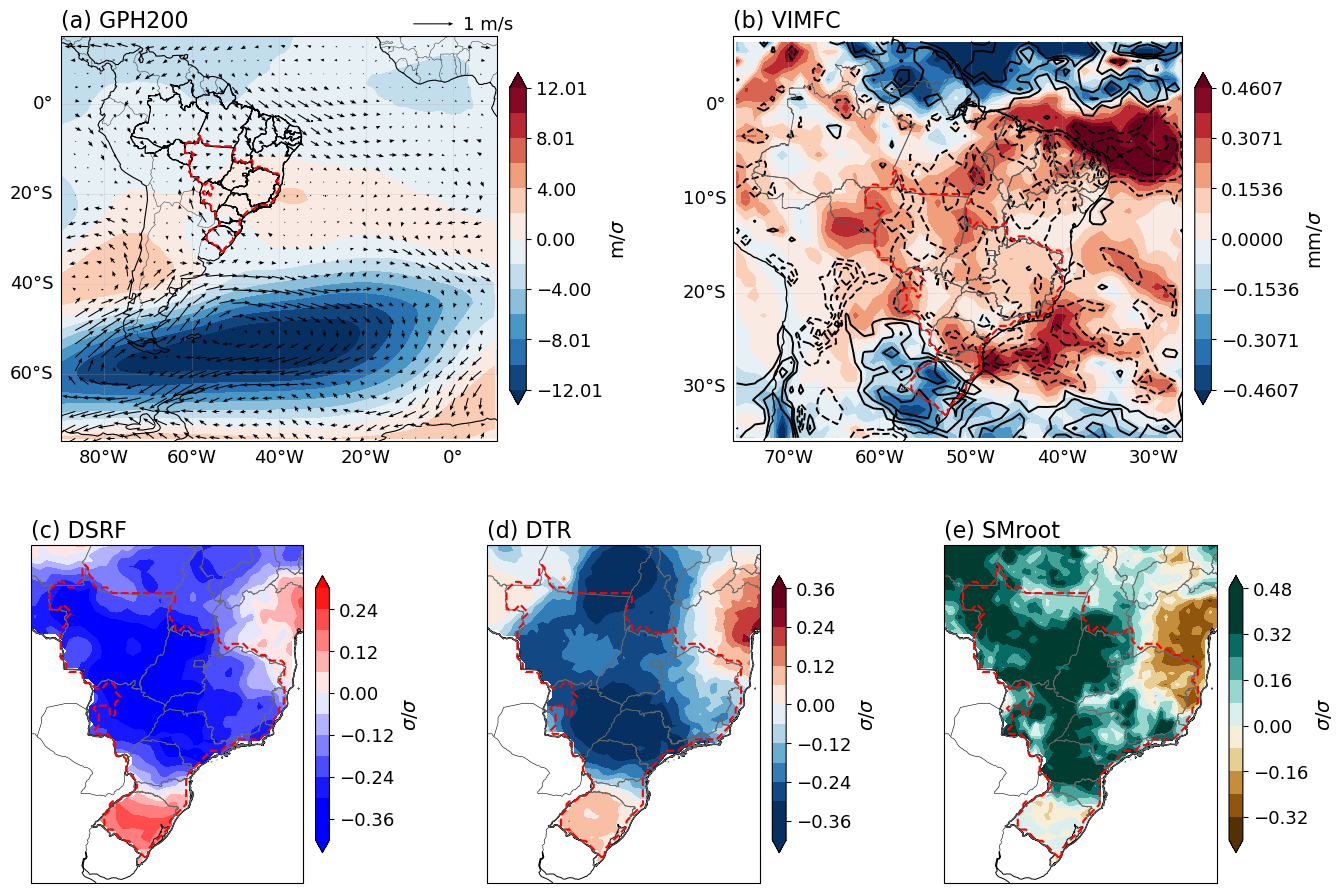

In [226]:
plot_jfm_ad_ond_5panel(
    hgt_reg=hgt200_AMJ_SASIC_AMJ,
    u_reg=uwnd850_AMJ_SASIC_AMJ,
    v_reg=vwnd850_AMJ_SASIC_AMJ,
    vimd_reg=vimd_AMJ_SASIC_AMJ,
    omega_reg=w_AMJ_SASIC_AMJ,

    lower1_reg=msdwswrf_AMJ_SASIC_AMJ,
    lower2_reg=dtr_AMJ_SASIC_AMJ,
    lower3_reg=smroot_AMJ_SASIC_AMJ,
    lower_titles=['DSRF', 'DTR', 'SMroot'],

    Brazil=Brazil,
    BRA_shp=BRA_shp,
    state_gdf=Brazil,
    maize2d=maize2d,
    country_gdf=BRA_shp,
    savepath="/Volumes/limenghan/巴西玉米/南极偶极子与环流/Figure10_AMJ_SASIC_AMJ_5panel_case2.png",
    fontsize_title=16,
    fontsize_tick=13,
    fontsize_cbar=14
)

In [227]:
w

<xarray.DataArray (time: 480, lat: 180, lon: 360)>
array([[[ 1.09156519e-02,  1.08625256e-02,  1.08115096e-02, ...,
          1.11756604e-02,  1.10815251e-02,  1.09980302e-02],
        [ 4.12546704e-03,  3.83984926e-03,  3.62317171e-03, ...,
          5.22014219e-03,  4.81721666e-03,  4.44990257e-03],
        [ 6.81037176e-03,  5.74496947e-03,  4.88938252e-03, ...,
          1.02333417e-02,  9.16025043e-03,  7.97523931e-03],
        ...,
        [ 1.43032707e-02,  1.58431418e-02,  1.71273034e-02, ...,
          9.56698973e-03,  1.10453609e-02,  1.26572233e-02],
        [ 1.12093985e-02,  1.12488233e-02,  1.12364776e-02, ...,
          1.13515481e-02,  1.12721585e-02,  1.12201320e-02],
        [ 1.42615521e-02,  1.43042570e-02,  1.43247563e-02, ...,
          1.39088538e-02,  1.40598845e-02,  1.41769117e-02]],

       [[-1.23049431e-02, -1.23618906e-02, -1.24236215e-02, ...,
         -1.21228565e-02, -1.21724308e-02, -1.22449566e-02],
        [-2.35434640e-02, -2.38128528e-02, -2.40926147e-02, ...,
         -2.30746195e-02, -2.31840331e-02, -2.33461633e-02],
        [-3.08297090e-02, -3.05386838e-02, -3.03030182e-02, ...,
         -3.16676311e-02, -3.14409658e-02, -3.11455727e-02],
...
          1.17353434e-02,  1.35684153e-02,  1.61003694e-02],
        [ 1.60950273e-02,  1.64267011e-02,  1.68436188e-02, ...,
          1.59109831e-02,  1.58231463e-02,  1.58764888e-02],
        [ 1.18945353e-02,  1.21518383e-02,  1.24020381e-02, ...,
          1.10871475e-02,  1.13547128e-02,  1.16188321e-02]],

       [[-6.27158303e-03, -6.38464559e-03, -6.49405783e-03, ...,
         -5.96768735e-03, -6.05131034e-03, -6.15394767e-03],
        [-4.74250130e-03, -4.90013929e-03, -5.08682802e-03, ...,
         -4.45698854e-03, -4.55429871e-03, -4.64320043e-03],
        [ 1.10064470e-03,  1.01919344e-03,  1.00309448e-03, ...,
          1.55055313e-03,  1.35673699e-03,  1.20790966e-03],
        ...,
        [-3.68051901e-02, -3.82608734e-02, -3.87752131e-02, ...,
         -2.90962122e-02, -3.19235995e-02, -3.46096978e-02],
        [-1.98458731e-02, -2.01287363e-02, -2.03472935e-02, ...,
         -1.91491675e-02, -1.93008482e-02, -1.95464697e-02],
        [-1.43844187e-02, -1.43438615e-02, -1.42795257e-02, ...,
         -1.43028768e-02, -1.43706314e-02, -1.43843768e-02]]],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2019-12-01
  * lat      (lat) float32 89.62 88.62 87.62 86.62 ... -87.38 -88.38 -89.38
  * lon      (lon) float32 0.375 1.375 2.375 3.375 ... 356.4 357.4 358.4 359.4